### Integrantes: Javiera Freire, Isidora Riquelme, Benjamín Soto

## ----> Parte 0.1, carga y preparación de datos

In [1]:
import pandas as pd

#Primero quiero ver todas las variables que hay en el dataset para ver si está correcto, se suto que agregar un encoding y la separación de las columnas con un ;
df_matricula = pd.read_csv("../Datos/matricula_completo.csv", sep=";", encoding="latin1")
print("Columnas de matricula_completo.csv:")
print(df_matricula.columns.tolist())
print("\n" + "="*80 + "\n")
df_postulaciones = pd.read_csv("../Datos/postulaciones_longer_1219.csv", sep=";", encoding="latin1")
print("Columnas de postulaciones_longer_1219.csv:")
print(df_postulaciones.columns.tolist())

C:\Users\benja\AppData\Local\Temp\ipykernel_14764\494051152.py:4: DtypeWarning: Columns (0: LYC_ANTERIOR) have mixed types. Specify dtype option on import or set low_memory=False.
  df_matricula = pd.read_csv("../Datos/matricula_completo.csv", sep=";", encoding="latin1")


Columnas de matricula_completo.csv:
['MRUNANIO', 'coherence_5_0.05_', 'coherence_5_0.01_', 'coherence_5_0.001_', 'coherence_5_0.0001_', 'coherence_10_0.05_', 'coherence_10_0.01_', 'coherence_10_0.001_', 'coherence_10_0.0001_', 'ANIO_ING_CARR_ORI', 'MRUN', 'COD_INST_CARR', 'CODIGO_UNICO', 'COD_INST', 'CODIGO_DEMRE', 'COD_CARRERA', 'CAT_PERIODO_0', 'CAT_PERIODO_1', 'CAT_PERIODO_2', 'CAT_PERIODO_3', 'CAT_PERIODO_4', 'CAT_PERIODO_5', 'ANYO_PROCESO', 'CODIGO_CARRERA', 'NOMBRE_CARRERA', 'SEDE_CARRERA', 'SIGLA_UNIVERSIDAD', 'PREFERENCIA', 'PUNTAJE_PONDERADO', 'LUGAR', 'POND_ANYO_ACAD', 'CODIGO_CARRERAOLD', 'COD_SEXO', 'FECHA_NACIMIENTO.x', 'RBD', 'RAMA_EDUCACIONAL', 'GRUPO_DEPENDENCIA', 'CODIGO_REGION_EGRESO', 'NOMBRE_REGION_EGRESO', 'CODIGO_PROVINCIA_EGRESO', 'NOMBRE_PROVINCIA_EGRESO', 'CODIGO_COMUNA_EGRESO', 'NOMBRE_COMUNA_EGRESO', 'ANYO_EGRESO', 'PROMEDIO_NOTAS', 'PUNTAJES_PROCESO', 'PTJE_NEM', 'PTJE_RANKING', 'LYC_ACTUAL', 'MATE_ACTUAL', 'HYCS_ACTUAL', 'CIENCIAS_ACTUAL', 'PROMLM_ACTUAL', 

C:\Users\benja\AppData\Local\Temp\ipykernel_14764\494051152.py:8: DtypeWarning: Columns (0: NOMBRE_CARRERA, 1: SEDE_CARRERA, 2: SIGLA_UNIVERSIDAD, 3: BEA) have mixed types. Specify dtype option on import or set low_memory=False.
  df_postulaciones = pd.read_csv("../Datos/postulaciones_longer_1219.csv", sep=";", encoding="latin1")


Columnas de postulaciones_longer_1219.csv:
['Unnamed: 0', 'TIPO_IDENTIFICACION', 'MRUN', 'ANYO_PROCESO', 'SITUACION_POSTULANTE', 'PREFERENCIA', 'CODIGO_CARRERA', 'NOMBRE_CARRERA', 'SEDE_CARRERA', 'SIGLA_UNIVERSIDAD', 'ESTADO_PREFERENCIA', 'PUNTAJE', 'LUGAR', 'POND_ANYO_ACAD', 'BEA', 'Knowledge_Area ID', 'Knowledge_Area', 'OECD_Area ID', 'OECD_Area', 'OECD_Subarea ID', 'OECD_Subarea', 'Generic_Career ID', 'Generic_Career', 'Career', 'Students']


## ----> Parte 0.2, Variables mínimas sugeridas

In [2]:
if "Unnamed: 0" in df_postulaciones.columns:
    df_postulaciones.drop(columns=["Unnamed: 0"], inplace=True)

if "MRUNANIO" not in df_postulaciones.columns:
    df_postulaciones["MRUN"] = df_postulaciones["MRUN"].astype(str)
    df_postulaciones["ANYO_PROCESO"] = df_postulaciones["ANYO_PROCESO"].astype(str)
    df_postulaciones["MRUNANIO"] = df_postulaciones["MRUN"] + "-" + df_postulaciones["ANYO_PROCESO"]

df_post_min = df_postulaciones[
    ["MRUNANIO", "MRUN", "ANYO_PROCESO", "Generic_Career ID"]
].copy()

display(df_post_min.head())

print("Filas totales:", len(df_post_min))
print("MRUNANIO únicos:", df_post_min["MRUNANIO"].nunique())
print("Cantidad de columnas:", len(df_post_min.columns))

,MRUNANIO,MRUN,ANYO_PROCESO,Generic_Career ID
0,2950920-2012,2950920,2012,2.0
1,2950920-2012,2950920,2012,36.0
2,2950920-2012,2950920,2012,25.0
3,2950920-2012,2950920,2012,17.0
4,22388130-2012,22388130,2012,46.0


Filas totales: 4670560
MRUNANIO únicos: 957536
Cantidad de columnas: 4


In [3]:
# Corrección de PUNTAJE_PONDERADO
df_matricula['PUNTAJE_PONDERADO'] = pd.to_numeric(df_matricula['PUNTAJE_PONDERADO'], errors='coerce').astype(float)

n_iter = 0
while (df_matricula['PUNTAJE_PONDERADO'] > 1000).any():
    mask = df_matricula['PUNTAJE_PONDERADO'] > 1000
    df_matricula.loc[mask, 'PUNTAJE_PONDERADO'] /= 100
    n_iter += 1

print(f"Iteraciones necesarias: {n_iter}")
print(f"Rango post-corrección: {df_matricula['PUNTAJE_PONDERADO'].min():.1f} – {df_matricula['PUNTAJE_PONDERADO'].max():.1f}")
print(f"Media: {df_matricula['PUNTAJE_PONDERADO'].mean():.1f}")


#FIltramos las columnas que nos interesan, le cambiamos el nombre a algunas para mayor comodidad y visualizamos las primeras filas para corroborar que está bien. Adicionalmente agregamos una variable "CODIGO_COMUNA_DOMICILIO para tener una referencia como código de la comuna.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

df_min = df_matricula[
    [
        "MRUNANIO",
        "MRUN",
        "ANYO_PROCESO",
        "coherence_5_0.05_",
        "GenericCareerID",
        "CAT_PERIODO_1",
        "PUNTAJE_PONDERADO",
        "COD_SEXO",
        "PREFERENCIA",
        "LUGAR",
        "RBD",
        "GRUPO_DEPENDENCIA",
        "NOMBRE_COMUNA_DOMICILIO",
        "Age",
        "CODIGO_COMUNA_DOMICILIO"
    ]
].rename(columns={
    "GRUPO_DEPENDENCIA": "DEPENDENCIA",
    "Age": "age"
})

print("Cantidad de filas:", len(df_min))
print("Cantidad de columnas:", len(df_min.columns))

display(df_min.head())



Iteraciones necesarias: 2
Rango post-corrección: 354.0 – 969.0
Media: 611.5
Cantidad de filas: 655004
Cantidad de columnas: 15


,MRUNANIO,MRUN,ANYO_PROCESO,coherence_5_0.05_,GenericCareerID,CAT_PERIODO_1,PUNTAJE_PONDERADO,COD_SEXO,PREFERENCIA,LUGAR,RBD,DEPENDENCIA,NOMBRE_COMUNA_DOMICILIO,age,CODIGO_COMUNA_DOMICILIO
1,10000269-2012,10000269,2012,0.166667,89.0,1,564.9,1,1,20,17907.0,3.0,CHILLAN,20,8401
2,10000325-2012,10000325,2012,0.200000,212.0,1,684.4,2,2,21,429.0,3.0,COPIAPO,22,3101
3,1000070-2012,1000070,2012,0.666667,204.0,1,544.6,2,3,47,217.0,1.0,CALAMA,20,2201
4,10001229-2012,10001229,2012,0.000000,192.0,1,542.9,1,1,40,3165.0,2.0,CONSTITUCION,23,7102
5,1000146-2012,1000146,2012,0.000000,63.0,1,572.5,2,1,51,1757.0,3.0,VI<d1>A DEL MAR,19,5109


## ----> Parte 0.3, Preprocesamiento

### --> 0.3.1 Construcción de la base final a nivel de MRUNANIO

In [4]:
# Revisamos si matrícula está prácticamente a nivel de MRUNANIO
print("Filas en df_min:", len(df_min))
print("MRUNANIO únicos en df_min:", df_min["MRUNANIO"].nunique())

base_matricula = df_min.drop_duplicates(subset="MRUNANIO").copy()

if "MRUNANIO" not in df_postulaciones.columns:
    df_postulaciones["MRUN"] = df_postulaciones["MRUN"].astype(str)
    df_postulaciones["ANYO_PROCESO"] = df_postulaciones["ANYO_PROCESO"].astype(str)
    df_postulaciones["MRUNANIO"] = df_postulaciones["MRUN"] + "-" + df_postulaciones["ANYO_PROCESO"]

resumen_post = (
    df_postulaciones[["MRUNANIO", "Generic_Career ID"]]
    .groupby("MRUNANIO")
    .agg(
        n_postulaciones=("Generic_Career ID", "count"),
        n_carreras_distintas=("Generic_Career ID", "nunique")
    )
    .reset_index()
)

print("\nFilas en resumen_post:", len(resumen_post))
print("MRUNANIO únicos en resumen_post:", resumen_post["MRUNANIO"].nunique())

base_final = base_matricula.merge(resumen_post, on="MRUNANIO", how="left")

base_final["n_postulaciones"] = base_final["n_postulaciones"].fillna(0)
base_final["n_carreras_distintas"] = base_final["n_carreras_distintas"].fillna(0)

print("\nFilas en base_final:", len(base_final))
print("MRUNANIO únicos en base_final:", base_final["MRUNANIO"].nunique())
print("Cantidad de columnas en base_final:", len(base_final.columns))

display(base_final.head())

Filas en df_min: 655004
MRUNANIO únicos en df_min: 655000

Filas en resumen_post: 957536
MRUNANIO únicos en resumen_post: 957536

Filas en base_final: 655000
MRUNANIO únicos en base_final: 655000
Cantidad de columnas en base_final: 17


,MRUNANIO,MRUN,ANYO_PROCESO,coherence_5_0.05_,GenericCareerID,CAT_PERIODO_1,PUNTAJE_PONDERADO,COD_SEXO,PREFERENCIA,LUGAR,RBD,DEPENDENCIA,NOMBRE_COMUNA_DOMICILIO,age,CODIGO_COMUNA_DOMICILIO,n_postulaciones,n_carreras_distintas
0,10000269-2012,10000269,2012,0.166667,89.0,1,564.9,1,1,20,17907.0,3.0,CHILLAN,20,8401,4,2
1,10000325-2012,10000325,2012,0.200000,212.0,1,684.4,2,2,21,429.0,3.0,COPIAPO,22,3101,6,3
2,1000070-2012,1000070,2012,0.666667,204.0,1,544.6,2,3,47,217.0,1.0,CALAMA,20,2201,4,3
3,10001229-2012,10001229,2012,0.000000,192.0,1,542.9,1,1,40,3165.0,2.0,CONSTITUCION,23,7102,6,1
4,1000146-2012,1000146,2012,0.000000,63.0,1,572.5,2,1,51,1757.0,3.0,VI<d1>A DEL MAR,19,5109,1,1


### --> 0.3.2 Selección de variables para clustering

In [5]:
#Selección final de variables para clustering

cluster_base = base_final[
    [
        "MRUNANIO",
        "PUNTAJE_PONDERADO",
        "age",
        "coherence_5_0.05_",
        "PREFERENCIA",
        "LUGAR",
        "COD_SEXO",
        "DEPENDENCIA",
        "n_postulaciones",
        "CAT_PERIODO_1"
    ]
].copy()

print("Filas en cluster_base:", len(cluster_base))
print("Cantidad de columnas en cluster_base:", len(cluster_base.columns))

display(cluster_base.head())

Filas en cluster_base: 655000
Cantidad de columnas en cluster_base: 10


,MRUNANIO,PUNTAJE_PONDERADO,age,coherence_5_0.05_,PREFERENCIA,LUGAR,COD_SEXO,DEPENDENCIA,n_postulaciones,CAT_PERIODO_1
0,10000269-2012,564.9,20,0.166667,1,20,1,3.0,4,1
1,10000325-2012,684.4,22,0.200000,2,21,2,3.0,6,1
2,1000070-2012,544.6,20,0.666667,3,47,2,1.0,4,1
3,10001229-2012,542.9,23,0.000000,1,40,1,2.0,6,1
4,1000146-2012,572.5,19,0.000000,1,51,2,3.0,1,1


Se excluteb las siguientes variables ya que:
- RBD: se excluye porque es un identificador del establecimiento y su valor no tiene interpretación métrica para el clustering.
- NOMBRE_COMUNA_DOMICILIO: se excluye porque tiene muchas categorías, lo que podía fragmentar innecesariamente los grupos.
- GenericCareerID: se excluye porque también tiene alta cardinalidad y podía hacer que los clusters se formaran por carrera más que por perfil estudiantil.

### --> 0.3.3 Revisión de valores faltantes

In [6]:
print("Valores faltantes por variable:")
display(cluster_base.isnull().sum().to_frame("Nulos"))

Valores faltantes por variable:


,Nulos
MRUNANIO,0
PUNTAJE_PONDERADO,0
age,0
coherence_5_0.05_,177
PREFERENCIA,0
LUGAR,0
COD_SEXO,0
DEPENDENCIA,758
n_postulaciones,0
CAT_PERIODO_1,0


### --> 0.3.4 Tratamiento de faltantes, recodificación y estandarización

In [7]:
from sklearn.preprocessing import StandardScaler
import numpy as np


cluster_df = cluster_base.copy()

cluster_df["n_postulaciones"] = np.log1p(cluster_df["n_postulaciones"])
cat_periodo_eval = cluster_df[["MRUNANIO", "CAT_PERIODO_1"]].copy()

vars_numericas = [
    "PUNTAJE_PONDERADO",
    "age",
    "coherence_5_0.05_",
    "PREFERENCIA",
    "LUGAR",
    "n_postulaciones"
]

vars_categoricas = [
    "COD_SEXO",
    "DEPENDENCIA"
]

for col in vars_numericas:
    cluster_df[col] = pd.to_numeric(cluster_df[col], errors="coerce")

for col in vars_numericas:
    cluster_df[col] = cluster_df[col].fillna(cluster_df[col].median())

for col in vars_categoricas:
    moda = cluster_df[col].mode(dropna=True)
    if len(moda) > 0:
        cluster_df[col] = cluster_df[col].fillna(moda.iloc[0])
    else:
        cluster_df[col] = cluster_df[col].fillna("Missing")
    cluster_df[col] = cluster_df[col].astype(str)

cluster_df = pd.get_dummies(cluster_df, columns=vars_categoricas, drop_first=True)

ids_cluster = cluster_df["MRUNANIO"].copy()

X_cluster = cluster_df.drop(columns=["MRUNANIO", "CAT_PERIODO_1"]).copy()

scaler = StandardScaler()
X_cluster[vars_numericas] = scaler.fit_transform(X_cluster[vars_numericas])

X_cluster = X_cluster.astype(float)

print("Dimensión final para clustering:", X_cluster.shape)
display(X_cluster.head())

Dimensión final para clustering: (655000, 13)


,PUNTAJE_PONDERADO,age,coherence_5_0.05_,PREFERENCIA,LUGAR,n_postulaciones,COD_SEXO_2,DEPENDENCIA_1.0,DEPENDENCIA_2.0,DEPENDENCIA_3.0,DEPENDENCIA_4.0,DEPENDENCIA_5.0,DEPENDENCIA_6.0
0,-0.642926,-0.279985,-0.650776,-0.524621,-0.555497,-0.180799,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,1.006922,0.641517,-0.600926,0.127015,-0.543098,0.612182,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.923193,-0.279985,0.096979,0.778652,-0.220704,-0.180799,1.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.946664,1.102268,-0.900028,-0.524621,-0.307503,0.612182,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-0.537998,-0.740736,-0.900028,-0.524621,-0.171105,-2.340266,1.0,0.0,0.0,1.0,0.0,0.0,0.0


#### --> Verificación final de la matriz para clustering

In [8]:
print("Filas finales para clustering:", len(X_cluster))
print("Columnas finales para clustering:", len(X_cluster.columns))
print("Total de nulos en X_cluster:", X_cluster.isnull().sum().sum())

Filas finales para clustering: 655000
Columnas finales para clustering: 13
Total de nulos en X_cluster: 0


In [9]:
sorted(base_final["DEPENDENCIA"].dropna().unique())

[np.float64(0.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(4.0),
 np.float64(5.0),
 np.float64(6.0)]

## ----> Parte 0.4, Sugerencias de Variables para Clustering

### --> 0.4.1 Variables seleccionadas

In [10]:
variables_finales_cluster = [
    "PUNTAJE_PONDERADO",
    "age",
    "coherence_5_0.05_",
    "PREFERENCIA",
    "LUGAR",
    "COD_SEXO",
    "DEPENDENCIA",
    "n_postulaciones"
]

print("Variables finales seleccionadas para clustering:")
for i, var in enumerate(variables_finales_cluster, 1):
    print(f"{i}. {var}")

Variables finales seleccionadas para clustering:
1. PUNTAJE_PONDERADO
2. age
3. coherence_5_0.05_
4. PREFERENCIA
5. LUGAR
6. COD_SEXO
7. DEPENDENCIA
8. n_postulaciones


### --> 0.4.2 Variable reservada para interpretación posterior

In [11]:
print("Variable reservada para análisis posterior:")
print("CAT_PERIODO_1")

Variable reservada para análisis posterior:
CAT_PERIODO_1


### --> 0.4.3 Verificación de redundancia básica entre variables numéricas

In [12]:
vars_numericas_revision = [
    "PUNTAJE_PONDERADO",
    "age",
    "coherence_5_0.05_",
    "PREFERENCIA",
    "LUGAR",
    "n_postulaciones"
]

corr_matrix = cluster_base[vars_numericas_revision].corr()

display(corr_matrix)

,PUNTAJE_PONDERADO,age,coherence_5_0.05_,PREFERENCIA,LUGAR,n_postulaciones
PUNTAJE_PONDERADO,1.000000,-0.091963,-0.128929,-0.105357,0.019571,-0.061676
age,-0.091963,1.000000,0.034997,-0.012195,-0.049632,-0.051763
coherence_5_0.05_,-0.128929,0.034997,1.000000,-0.071907,-0.119631,-0.007015
PREFERENCIA,-0.105357,-0.012195,-0.071907,1.000000,-0.004119,0.282290
LUGAR,0.019571,-0.049632,-0.119631,-0.004119,1.000000,0.030244
n_postulaciones,-0.061676,-0.051763,-0.007015,0.282290,0.030244,1.000000


### --> 0.4.4 Frecuencia de variables categóricas seleccionadas

In [13]:
print("Frecuencia de COD_SEXO:")
display(cluster_base["COD_SEXO"].value_counts(dropna=False).sort_index())

print("\nFrecuencia de DEPENDENCIA:")
display(cluster_base["DEPENDENCIA"].value_counts(dropna=False).sort_index())

Frecuencia de COD_SEXO:


COD_SEXO
1    324963
2    330037
Name: count, dtype: int64


Frecuencia de DEPENDENCIA:


DEPENDENCIA
0.0      3362
1.0     48380
2.0    100468
3.0    344584
4.0    144611
5.0     12268
6.0       569
NaN       758
Name: count, dtype: int64

## ----> Parte 1, Construcción de la Base Analítica

### --> 1.1 Integración de datos

In [14]:
print("Dimensión de la base final:", base_final.shape)
print("MRUNANIO únicos en base_final:", base_final["MRUNANIO"].nunique())
print("Cantidad de columnas en base_final:", len(base_final.columns))

display(base_final.head())

Dimensión de la base final: (655000, 17)
MRUNANIO únicos en base_final: 655000
Cantidad de columnas en base_final: 17


,MRUNANIO,MRUN,ANYO_PROCESO,coherence_5_0.05_,GenericCareerID,CAT_PERIODO_1,PUNTAJE_PONDERADO,COD_SEXO,PREFERENCIA,LUGAR,RBD,DEPENDENCIA,NOMBRE_COMUNA_DOMICILIO,age,CODIGO_COMUNA_DOMICILIO,n_postulaciones,n_carreras_distintas
0,10000269-2012,10000269,2012,0.166667,89.0,1,564.9,1,1,20,17907.0,3.0,CHILLAN,20,8401,4,2
1,10000325-2012,10000325,2012,0.200000,212.0,1,684.4,2,2,21,429.0,3.0,COPIAPO,22,3101,6,3
2,1000070-2012,1000070,2012,0.666667,204.0,1,544.6,2,3,47,217.0,1.0,CALAMA,20,2201,4,3
3,10001229-2012,10001229,2012,0.000000,192.0,1,542.9,1,1,40,3165.0,2.0,CONSTITUCION,23,7102,6,1
4,1000146-2012,1000146,2012,0.000000,63.0,1,572.5,2,1,51,1757.0,3.0,VI<d1>A DEL MAR,19,5109,1,1


In [15]:
print("Variables finales utilizadas en X_cluster:")
print(X_cluster.columns.tolist())

print("\nDimensión final de la matriz para clustering:", X_cluster.shape)

Variables finales utilizadas en X_cluster:
['PUNTAJE_PONDERADO', 'age', 'coherence_5_0.05_', 'PREFERENCIA', 'LUGAR', 'n_postulaciones', 'COD_SEXO_2', 'DEPENDENCIA_1.0', 'DEPENDENCIA_2.0', 'DEPENDENCIA_3.0', 'DEPENDENCIA_4.0', 'DEPENDENCIA_5.0', 'DEPENDENCIA_6.0']

Dimensión final de la matriz para clustering: (655000, 13)


### --> 1.2 Justificación de variables

La variable coherence_5_0.05_ se incorporó porque representa la coherencia de preferencias, es decir, qué tan alineado parece ser el patrón de postulación del estudiante. PUNTAJE_PONDERADO se utilizó para capturar una dimensión de desempeño académico, mientras que PREFERENCIA y LUGAR permiten aproximarse a la trayectoria de acceso, ya que reflejan cómo se posiciona el estudiante dentro de su proceso de postulación e ingreso.

Por otra parte, age y SEXO se consideraron como características individuales, ya que ayudan a distinguir perfiles personales dentro de la muestra. A su vez, DEPENDENCIA se incluyó como una aproximación al contexto escolar de origen del estudiante.

Finalmente, CAT_PERIODO_1 no se utilizó para construir los clusters, sino que se reservó para la interpretación posterior, con el fin de analizar si los grupos obtenidos también presentaban diferencias en esa variable sin influir directamente en su formación.

En cambio, n_postulaciones se dejó fuera de esta selección final, ya que se priorizó trabajar con variables que representaran de mejor manera las dimensiones principales del perfil estudiantil.

Pero finalmente, para el análisis, las variables utilizadas para el clustering fueron puntaje ponderado, edad, coherence_5_0.05, preferencia, lugar, n_postulaciones cod_sexo y dependencias

## ----> Parte 2, Aplicacion de ALgoritmos de Clustering

### --> 2.1 K-Means

In [16]:
import os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

X_np = X_cluster.values

resultados_kmeans = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=314, n_init=10)
    labels = kmeans.fit_predict(X_np)

    resultados_kmeans.append({
        "K": k,
        "Inertia": kmeans.inertia_,
        "Silhouette": silhouette_score(X_np, labels, sample_size=10000, random_state=314),
        "Davies_Bouldin": davies_bouldin_score(X_np, labels),
        "Calinski_Harabasz": calinski_harabasz_score(X_np, labels)
    })
    print(f"K={k} ✓")

resultados_kmeans = pd.DataFrame(resultados_kmeans)
display(resultados_kmeans)

K=2 ✓
K=3 ✓
K=4 ✓
K=5 ✓
K=6 ✓
K=7 ✓
K=8 ✓
K=9 ✓
K=10 ✓


,K,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,2,3.988766e+06,0.125847,2.501698,85947.347973
1,3,3.551981e+06,0.137268,2.059569,88530.275581
2,4,3.171987e+06,0.152843,1.753900,92246.188690
3,5,2.857186e+06,0.175639,1.571010,94848.623595
4,6,2.560558e+06,0.160627,1.524244,99844.613065
5,7,2.341627e+06,0.159441,1.431659,101189.362084
6,8,2.238983e+06,0.153550,1.519165,94999.312043
7,9,2.166179e+06,0.139793,1.561364,88669.794407
8,10,2.084649e+06,0.141891,1.522439,84746.378306


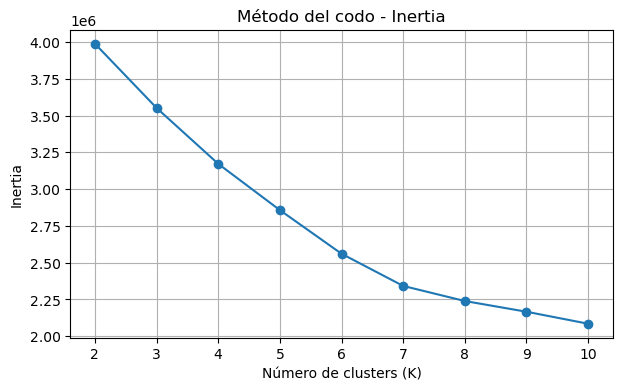

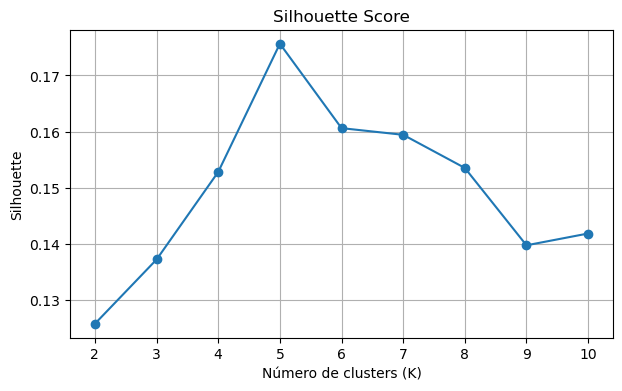

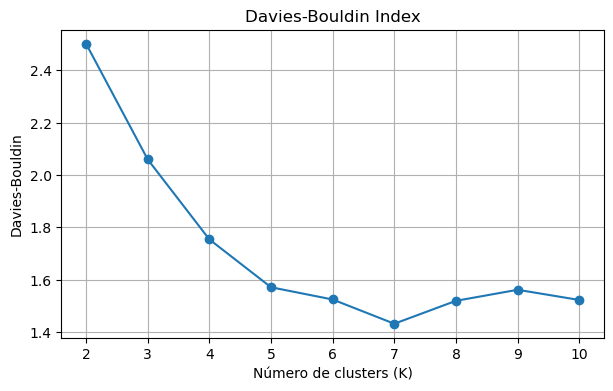

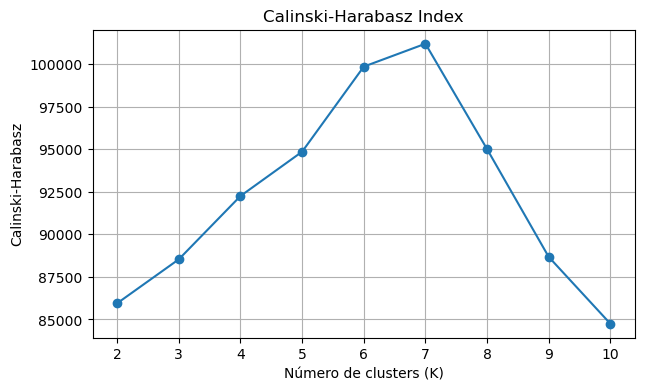

In [17]:
import matplotlib.pyplot as plt

# Inertia
plt.figure(figsize=(7,4))
plt.plot(resultados_kmeans["K"], resultados_kmeans["Inertia"], marker="o")
plt.title("Método del codo - Inertia")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# Silhouette
plt.figure(figsize=(7,4))
plt.plot(resultados_kmeans["K"], resultados_kmeans["Silhouette"], marker="o")
plt.title("Silhouette Score")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

# Davies-Bouldin
plt.figure(figsize=(7,4))
plt.plot(resultados_kmeans["K"], resultados_kmeans["Davies_Bouldin"], marker="o")
plt.title("Davies-Bouldin Index")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Davies-Bouldin")
plt.grid(True)
plt.show()

# Calinski-Harabasz
plt.figure(figsize=(7,4))
plt.plot(resultados_kmeans["K"], resultados_kmeans["Calinski_Harabasz"], marker="o")
plt.title("Calinski-Harabasz Index")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Calinski-Harabasz")
plt.grid(True)
plt.show()

Como se puede observar, los cluster ganadores en cada uno de las métricas son:
- Inertia: K=5,  ya que, como se puede observar en los la tabla con valores, es el que tiene un mejor cambio en la pendiente de la curva de Inertia.
- Silhouette: K=5  debido a que es el más alto, lo cual indica que los clusters están bien separados entre sí y que las observaciones están correctamente asignadas a su grupo.
- Davies-Bouldin: K=7  ya que es el más bajo. lo que indica que los clusters son más compactos y están mejor separados entre sí.
- Calinski-Harabasz: K=7,  ya que es el más alto, lo cual indica que tiene una mejor relación entre la dispersión entre clusters y la cohesión interna de los mismos.

En lo cual al juntar todas las métricas podemos ver que K=5 se comporta mejor y es más interpretable que K=7. Además se logra un buen equilibrio, los grupos se ven más claros y separados en los gráficos, ya que se puede ver una mejor repartición de los datos a pesar de que en el cluster 4 se encuentran demasiadas personas. Además, al aumentar k más allá de 5 no se observa una mejora, sino más bien una fragmentación innecesaria, por lo que k = 5 es la opción más razonable considerando cómo se comportan los datos en la práctica.

In [18]:
# Modelo final K-Means con K = 5
kmeans_final = KMeans(n_clusters=5, random_state=314, n_init=10)
labels_final = kmeans_final.fit_predict(X_np)

df_kmeans = X_cluster.copy()
df_kmeans["cluster_kmeans"] = labels_final

display(df_kmeans.head())

cluster_sizes = df_kmeans["cluster_kmeans"].value_counts().sort_index()
display(cluster_sizes)

perfil_clusters = df_kmeans.groupby("cluster_kmeans").mean()
display(perfil_clusters)


,PUNTAJE_PONDERADO,age,coherence_5_0.05_,PREFERENCIA,LUGAR,n_postulaciones,COD_SEXO_2,DEPENDENCIA_1.0,DEPENDENCIA_2.0,DEPENDENCIA_3.0,DEPENDENCIA_4.0,DEPENDENCIA_5.0,DEPENDENCIA_6.0,cluster_kmeans
0,-0.642926,-0.279985,-0.650776,-0.524621,-0.555497,-0.180799,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4
1,1.006922,0.641517,-0.600926,0.127015,-0.543098,0.612182,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4
2,-0.923193,-0.279985,0.096979,0.778652,-0.220704,-0.180799,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4
3,-0.946664,1.102268,-0.900028,-0.524621,-0.307503,0.612182,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4
4,-0.537998,-0.740736,-0.900028,-0.524621,-0.171105,-2.340266,1.0,0.0,0.0,1.0,0.0,0.0,0.0,4


cluster_kmeans
0     37453
1    159655
2     60816
3     38443
4    358633
Name: count, dtype: int64

,PUNTAJE_PONDERADO,age,coherence_5_0.05_,PREFERENCIA,LUGAR,n_postulaciones,COD_SEXO_2,DEPENDENCIA_1.0,DEPENDENCIA_2.0,DEPENDENCIA_3.0,DEPENDENCIA_4.0,DEPENDENCIA_5.0,DEPENDENCIA_6.0
cluster_kmeans,,,,,,,,,,,,,
0,-0.201440,2.980924,0.001337,-0.237698,-0.267347,-0.266091,0.424692,0.111874,0.235335,0.481457,0.115531,0.033829,0.001335
1,-0.403291,-0.134685,1.343083,-0.267991,-0.246313,-0.057369,0.456916,0.074335,0.204848,0.576850,0.112336,0.025543,0.001203
2,-0.338784,-0.110074,-0.271852,2.350514,-0.061885,0.977891,0.546156,0.080735,0.160451,0.563635,0.168508,0.020061,0.000723
3,0.518526,-0.193583,-0.384651,-0.186624,3.129806,-0.010650,0.412195,0.055667,0.065890,0.326223,0.541217,0.005645,0.000130
4,0.202440,-0.211931,-0.510717,-0.234462,-0.187427,-0.111359,0.535704,0.070468,0.130100,0.525311,0.254564,0.015297,0.000775


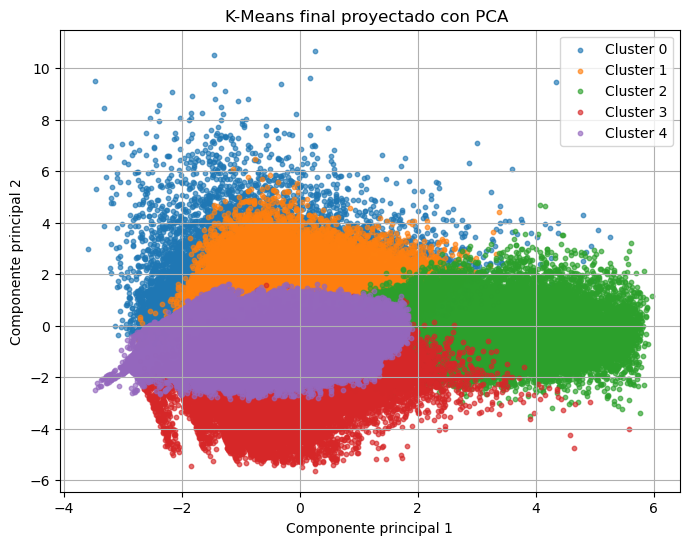

In [19]:
# VISUALIZACIÓN FINAL
from sklearn.decomposition import PCA

X_km_vis = df_kmeans.drop(columns=["cluster_kmeans"]).copy()
y_km_vis = df_kmeans["cluster_kmeans"].values

pca_km = PCA(n_components=2, random_state=314)
X_km_pca = pca_km.fit_transform(X_km_vis)

plt.figure(figsize=(8, 6))
for c in np.unique(y_km_vis):
    mask = y_km_vis == c
    plt.scatter(
        X_km_pca[mask, 0],
        X_km_pca[mask, 1],
        label=f"Cluster {c}",
        alpha=0.65,
        s=10
    )

plt.title("K-Means final proyectado con PCA ")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.grid(True)
plt.show()

### --> 2.2 Clustering Jerárquico

In [20]:
import os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore")

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

n_eval = min(3000, len(X_cluster))
n_dendro = min(800, n_eval) 

X_hier = X_cluster.sample(n=n_eval, random_state=314).copy()
X_dendro = X_hier.sample(n=n_dendro, random_state=314).copy()

print("Muestra para evaluación jerárquica:", X_hier.shape)
print("Muestra para dendrograma:", X_dendro.shape)

Muestra para evaluación jerárquica: (3000, 13)
Muestra para dendrograma: (800, 13)


Shape X_hier: (3000, 13)
Shape X_dendro: (800, 13)

Probando: ward + euclidean
K=2 ✓
K=3 ✓
K=4 ✓
K=5 ✓
K=6 ✓
K=7 ✓
K=8 ✓
K=9 ✓
K=10 ✓

Probando: average + euclidean
K=2 ✓
K=3 ✓
K=4 ✓
K=5 ✓
K=6 ✓
K=7 ✓
K=8 ✓
K=9 ✓
K=10 ✓

Probando: complete + manhattan
K=2 ✓
K=3 ✓
K=4 ✓
K=5 ✓
K=6 ✓
K=7 ✓
K=8 ✓
K=9 ✓
K=10 ✓

Probando: average + cosine
K=2 ✓
K=3 ✓
K=4 ✓
K=5 ✓
K=6 ✓
K=7 ✓
K=8 ✓
K=9 ✓
K=10 ✓

Probando: complete + cosine
K=2 ✓
K=3 ✓
K=4 ✓
K=5 ✓
K=6 ✓
K=7 ✓
K=8 ✓
K=9 ✓
K=10 ✓

Top según Silhouette (más alto mejor):


,linkage,metric,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
9,average,euclidean,2,0.666665,0.582140,150.951679
18,complete,manhattan,2,0.545580,0.649919,152.731856
10,average,euclidean,3,0.526199,0.665148,161.577005
11,average,euclidean,4,0.526199,0.632988,109.567580
12,average,euclidean,5,0.489962,0.678974,140.354161
13,average,euclidean,6,0.487538,0.788439,113.804746
14,average,euclidean,7,0.432825,0.761799,96.804923
15,average,euclidean,8,0.305685,0.948042,112.537172
16,average,euclidean,9,0.257637,0.982524,101.640633
17,average,euclidean,10,0.256691,0.957963,90.899507


Top según Davies-Bouldin (más bajo mejor):


,linkage,metric,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
9,average,euclidean,2,0.666665,0.582140,150.951679
11,average,euclidean,4,0.526199,0.632988,109.567580
18,complete,manhattan,2,0.545580,0.649919,152.731856
10,average,euclidean,3,0.526199,0.665148,161.577005
12,average,euclidean,5,0.489962,0.678974,140.354161
14,average,euclidean,7,0.432825,0.761799,96.804923
13,average,euclidean,6,0.487538,0.788439,113.804746
15,average,euclidean,8,0.305685,0.948042,112.537172
17,average,euclidean,10,0.256691,0.957963,90.899507
16,average,euclidean,9,0.257637,0.982524,101.640633


Top según Calinski-Harabasz (más alto mejor):


,linkage,metric,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
30,average,cosine,5,0.177845,1.918786,333.534536
0,ward,euclidean,2,0.228429,1.723559,327.729208
4,ward,euclidean,6,0.103620,1.751092,325.564736
3,ward,euclidean,5,0.101446,1.969799,322.836672
5,ward,euclidean,7,0.088088,1.717816,318.070416
2,ward,euclidean,4,0.099002,2.155332,314.770789
29,average,cosine,4,0.133730,1.919855,314.509825
1,ward,euclidean,3,0.100248,2.290132,312.169897
6,ward,euclidean,8,0.092056,1.588822,306.052825
7,ward,euclidean,9,0.095855,1.602012,298.664869


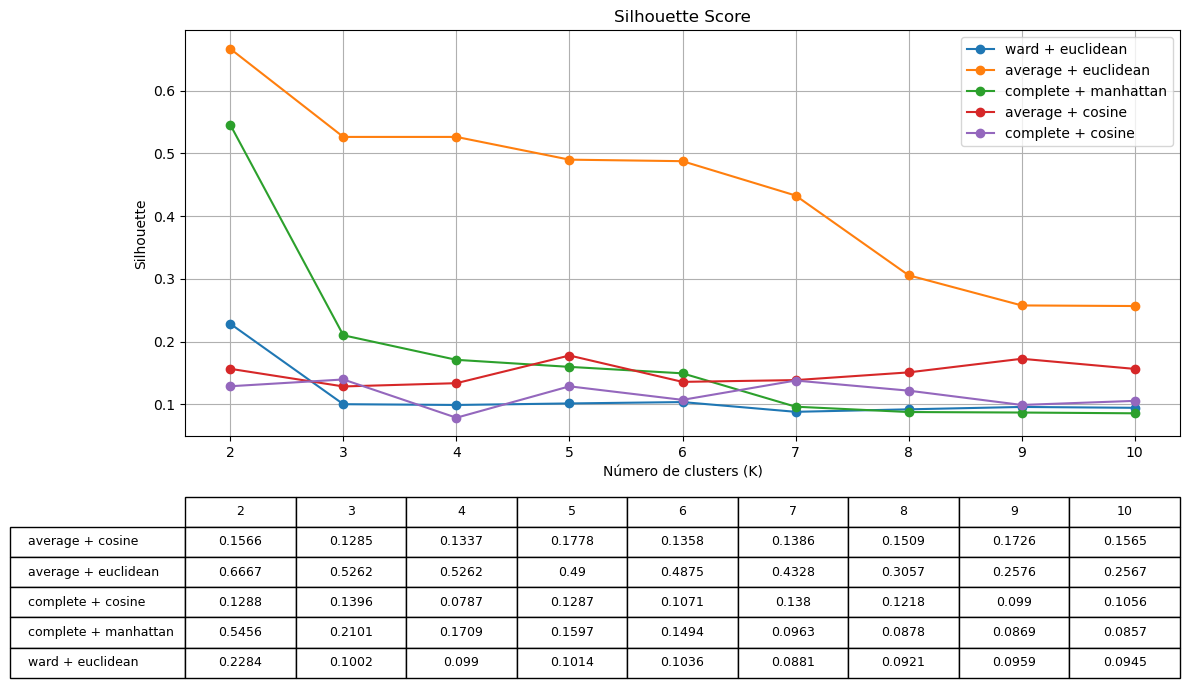

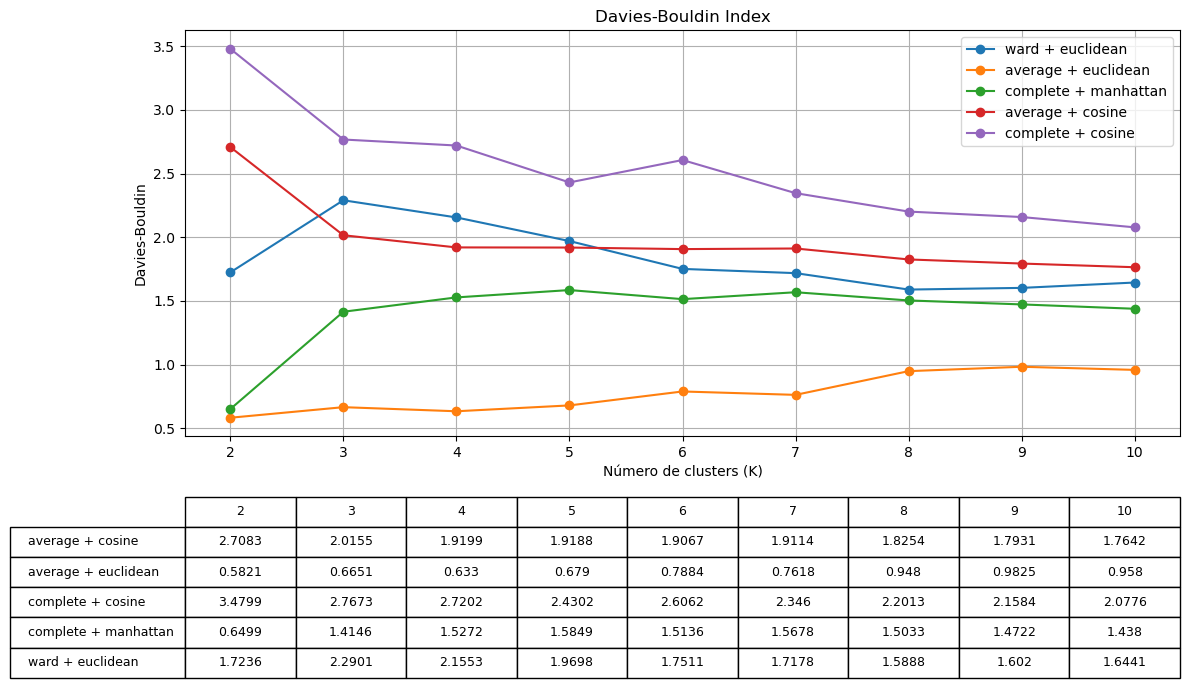

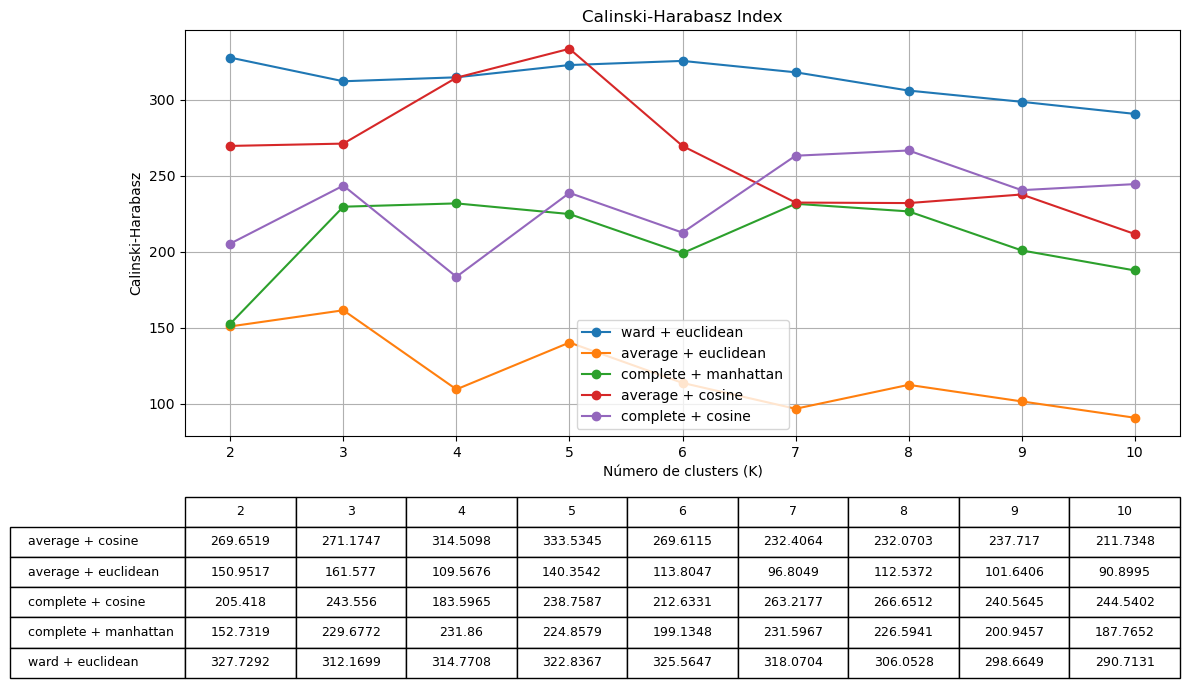


Mejor K por combinación según Silhouette:


,linkage,metric,K,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,average,euclidean,2,0.666665,0.582140,150.951679
1,complete,manhattan,2,0.545580,0.649919,152.731856
2,ward,euclidean,2,0.228429,1.723559,327.729208
3,average,cosine,5,0.177845,1.918786,333.534536
4,complete,cosine,3,0.139644,2.767346,243.556034


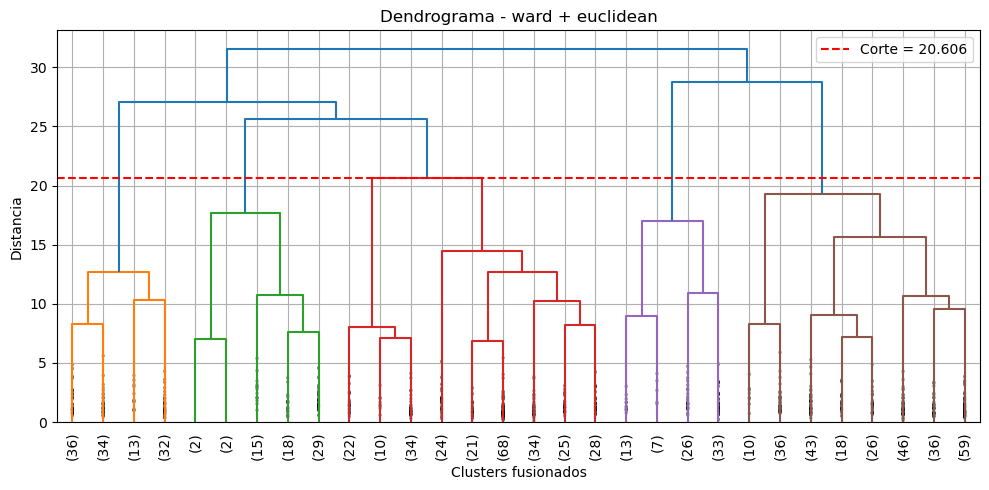

ward + euclidean
Corte sugerido: 20.6056
Número de clusters sugerido: 5


,Fusion,Distancia
0,1,14.500509
1,2,15.630244
2,3,17.020201
3,4,17.716018
4,5,19.245367
5,6,20.605561
6,7,25.657772
7,8,27.087416
8,9,28.712766
9,10,31.541935


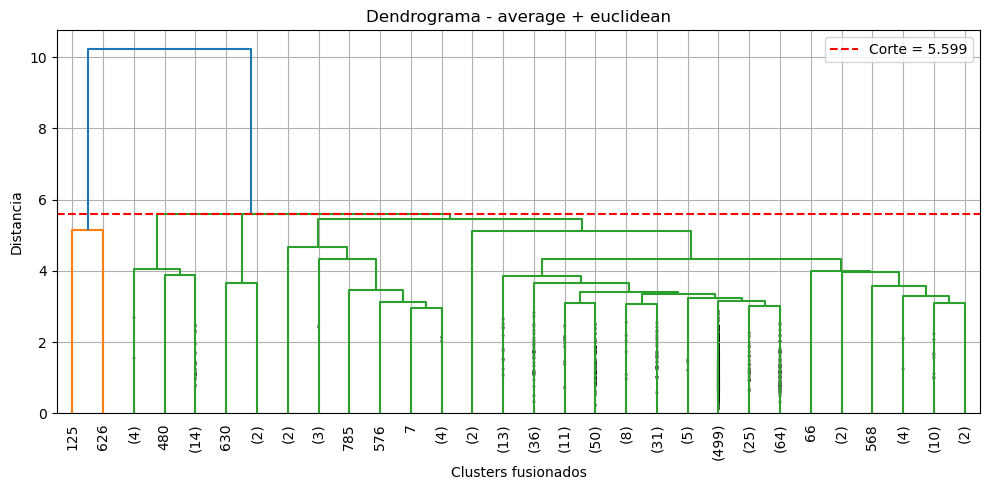

average + euclidean
Corte sugerido: 5.5988
Número de clusters sugerido: 2


,Fusion,Distancia
0,1,4.049772
1,2,4.324816
2,3,4.329761
3,4,4.670611
4,5,5.131777
5,6,5.152977
6,7,5.468971
7,8,5.591514
8,9,5.598753
9,10,10.241890


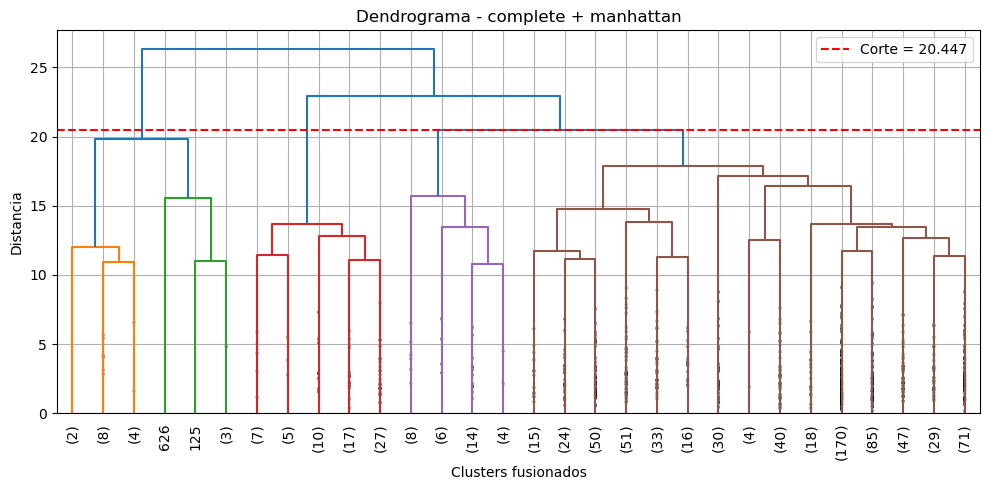

complete + manhattan
Corte sugerido: 20.4472
Número de clusters sugerido: 3


,Fusion,Distancia
0,1,14.771554
1,2,15.577516
2,3,15.704157
3,4,16.397791
4,5,17.162256
5,6,17.887534
6,7,19.816614
7,8,20.447171
8,9,22.951618
9,10,26.367083


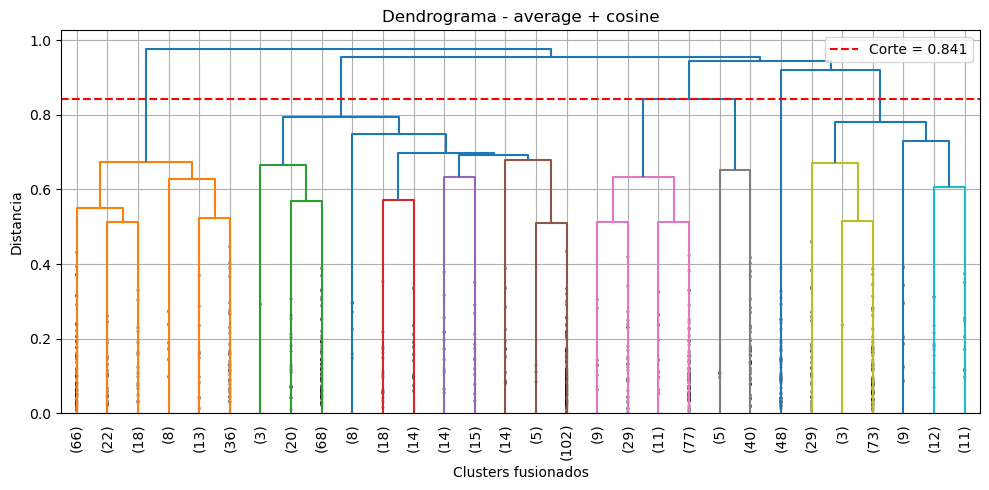

average + cosine
Corte sugerido: 0.8413
Número de clusters sugerido: 5


,Fusion,Distancia
0,1,0.698572
1,2,0.729185
2,3,0.748764
3,4,0.781809
4,5,0.795088
5,6,0.841277
6,7,0.921483
7,8,0.945572
8,9,0.954479
9,10,0.977653


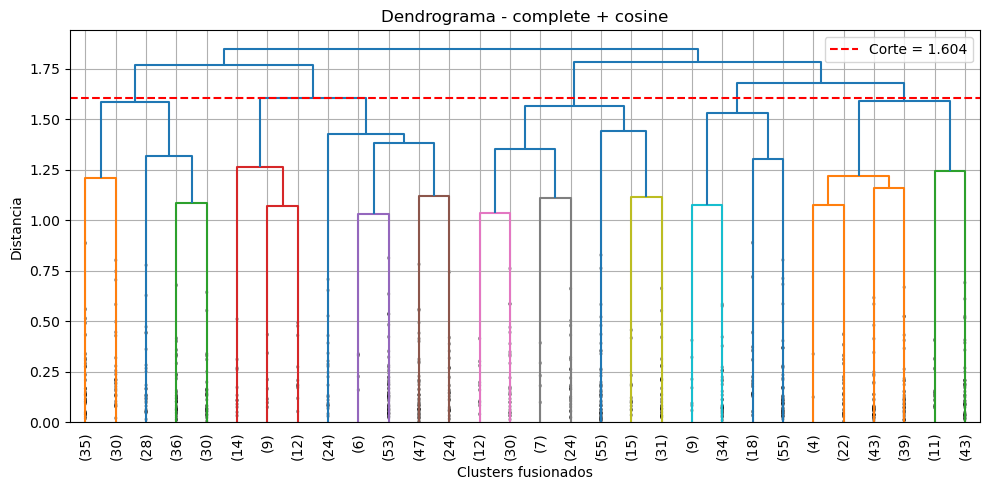

complete + cosine
Corte sugerido: 1.6038
Número de clusters sugerido: 5


,Fusion,Distancia
0,1,1.442652
1,2,1.530110
2,3,1.567875
3,4,1.583975
4,5,1.591493
5,6,1.603824
6,7,1.679719
7,8,1.770384
8,9,1.785113
9,10,1.847992



Resumen de cortes sugeridos por dendrograma:


,linkage,metric,cutoff,clusters_sugeridos
0,ward,euclidean,20.605561,5
1,average,euclidean,5.598753,2
2,complete,manhattan,20.447171,3
3,average,cosine,0.841277,5
4,complete,cosine,1.603824,5


In [21]:
import os
import warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore")
from matplotlib import gridspec

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

print("Shape X_hier:", X_hier.shape)
print("Shape X_dendro:", X_dendro.shape)

combinaciones = [
    {"linkage": "ward", "metric": "euclidean"},
    {"linkage": "average", "metric": "euclidean"},
    {"linkage": "complete", "metric": "manhattan"},
    {"linkage": "average", "metric": "cosine"},
    {"linkage": "complete", "metric": "cosine"}
]

k_values = range(2, 11)
resultados_hier = []

sil_sample_size = min(2000, len(X_hier))

for combo in combinaciones:
    linkage_name = combo["linkage"]
    metric_name = combo["metric"]

    print(f"\nProbando: {linkage_name} + {metric_name}")

    if linkage_name == "ward" and metric_name != "euclidean":
        print(f"Saltando combinación inválida: {linkage_name} + {metric_name}")
        continue

    for k in k_values:
        if linkage_name == "ward":
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage="ward"
            )
            labels = model.fit_predict(X_hier)

            sil = silhouette_score(
                X_hier,
                labels,
                metric="euclidean",
                sample_size=sil_sample_size,
                random_state=314
            )

        else:
            model = AgglomerativeClustering(
                n_clusters=k,
                linkage=linkage_name,
                metric=metric_name
            )
            labels = model.fit_predict(X_hier)

            sil = silhouette_score(
                X_hier,
                labels,
                metric=metric_name,
                sample_size=sil_sample_size,
                random_state=314
            )

        resultados_hier.append({
            "linkage": linkage_name,
            "metric": metric_name,
            "K": k,
            "Silhouette": sil,
            "Davies_Bouldin": davies_bouldin_score(X_hier, labels),
            "Calinski_Harabasz": calinski_harabasz_score(X_hier, labels)
        })

        print(f"K={k} ✓")

resultados_hier = pd.DataFrame(resultados_hier)

print("\nTop según Silhouette (más alto mejor):")
display(
    resultados_hier.sort_values(by="Silhouette", ascending=False).head(10)
)

print("Top según Davies-Bouldin (más bajo mejor):")
display(
    resultados_hier.sort_values(by="Davies_Bouldin", ascending=True).head(10)
)

print("Top según Calinski-Harabasz (más alto mejor):")
display(
    resultados_hier.sort_values(by="Calinski_Harabasz", ascending=False).head(10)
)

def graficar_metrica_con_tabla(df_resultados, combinaciones, metrica, titulo, ylabel):
    fig = plt.figure(figsize=(12, 7))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3.5, 1.6])

    ax_plot = fig.add_subplot(gs[0])

    for combo in combinaciones:
        filtro = (
            (df_resultados["linkage"] == combo["linkage"]) &
            (df_resultados["metric"] == combo["metric"])
        )
        df_plot = df_resultados[filtro].sort_values("K")
        if len(df_plot) == 0:
            continue
        etiqueta = f'{combo["linkage"]} + {combo["metric"]}'
        ax_plot.plot(df_plot["K"], df_plot[metrica], marker="o", label=etiqueta)

    ax_plot.set_title(titulo)
    ax_plot.set_xlabel("Número de clusters (K)")
    ax_plot.set_ylabel(ylabel)
    ax_plot.grid(True)
    ax_plot.legend()

    ax_table = fig.add_subplot(gs[1])
    ax_table.axis("off")

    df_tabla = df_resultados.copy()
    df_tabla["Combinación"] = df_tabla["linkage"] + " + " + df_tabla["metric"]

    tabla_pivot = df_tabla.pivot(
        index="Combinación",
        columns="K",
        values=metrica
    ).round(4)

    table = ax_table.table(
        cellText=tabla_pivot.values,
        rowLabels=tabla_pivot.index,
        colLabels=tabla_pivot.columns,
        loc="center",
        cellLoc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.5)

    plt.tight_layout()
    plt.show()

graficar_metrica_con_tabla(
    df_resultados=resultados_hier,
    combinaciones=combinaciones,
    metrica="Silhouette",
    titulo="Silhouette Score",
    ylabel="Silhouette"
)

graficar_metrica_con_tabla(
    df_resultados=resultados_hier,
    combinaciones=combinaciones,
    metrica="Davies_Bouldin",
    titulo="Davies-Bouldin Index",
    ylabel="Davies-Bouldin"
)

graficar_metrica_con_tabla(
    df_resultados=resultados_hier,
    combinaciones=combinaciones,
    metrica="Calinski_Harabasz",
    titulo="Calinski-Harabasz Index",
    ylabel="Calinski-Harabasz"
)

mejores_por_combo = (
    resultados_hier
    .sort_values(["linkage", "metric", "Silhouette"], ascending=[True, True, False])
    .groupby(["linkage", "metric"], as_index=False)
    .first()
    .sort_values("Silhouette", ascending=False)
    .reset_index(drop=True)
)

print("\nMejor K por combinación según Silhouette:")
display(mejores_por_combo)

def metric_for_scipy(metric_name):
    if metric_name == "manhattan":
        return "cityblock"
    return metric_name

def construir_Z(X, linkage_name, metric_name):
    X_np = np.asarray(X)

    if linkage_name == "ward":
        Z = linkage(X_np, method="ward")
    else:
        Z = linkage(
            X_np,
            method=linkage_name,
            metric=metric_for_scipy(metric_name)
        )

    return Z

def find_optimal_cutoff(Z, n_last=10):
    last = Z[-n_last:, 2]

    if len(last) < 3:
        return np.median(last)

    acceleration = np.diff(last, 2)
    acceleration_rev = acceleration[::-1]
    k = acceleration_rev.argmax() + 2

    cutoff = Z[-k, 2]
    return cutoff

def plot_dendrogram_with_cut(Z, title, cutoff, p=30):
    plt.figure(figsize=(10, 5))
    dendrogram(
        Z,
        truncate_mode="lastp",
        p=p,
        leaf_rotation=90,
        leaf_font_size=10,
        show_contracted=True
    )
    plt.axhline(y=cutoff, c="r", linestyle="--", label=f"Corte = {cutoff:.3f}")
    plt.title(title)
    plt.xlabel("Clusters fusionados")
    plt.ylabel("Distancia")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def count_clusters_from_cutoff(Z, cutoff):
    labels = fcluster(Z, t=cutoff, criterion="distance")
    return len(np.unique(labels)), labels

def tabla_ultimas_fusiones(Z, n=10):
    ultimas = Z[-n:, 2]
    return pd.DataFrame({
        "Fusion": range(1, len(ultimas) + 1),
        "Distancia": ultimas
    })

resumen_dendro = []

for combo in combinaciones:
    linkage_name = combo["linkage"]
    metric_name = combo["metric"]

    if linkage_name == "ward" and metric_name != "euclidean":
        continue

    Z = construir_Z(X_dendro, linkage_name, metric_name)
    cutoff = find_optimal_cutoff(Z, n_last=10)
    n_clusters_cut, labels_cut = count_clusters_from_cutoff(Z, cutoff)

    titulo = f"Dendrograma - {linkage_name} + {metric_name}"
    plot_dendrogram_with_cut(Z, titulo, cutoff, p=30)

    print(f"{linkage_name} + {metric_name}")
    print(f"Corte sugerido: {cutoff:.4f}")
    print(f"Número de clusters sugerido: {n_clusters_cut}")
    display(tabla_ultimas_fusiones(Z, n=10))

    resumen_dendro.append({
        "linkage": linkage_name,
        "metric": metric_name,
        "cutoff": cutoff,
        "clusters_sugeridos": n_clusters_cut
    })

resumen_dendro = pd.DataFrame(resumen_dendro)

print("\nResumen de cortes sugeridos por dendrograma:")
display(resumen_dendro)

In [22]:
evaluacion_final = resultados_hier.merge(
    resumen_dendro,
    on=["linkage", "metric"],
    how="inner"
)

evaluacion_final = evaluacion_final[
    (evaluacion_final["linkage"] == "ward") &
    (evaluacion_final["metric"] == "euclidean")
].copy()

evaluacion_final = evaluacion_final[
    evaluacion_final["K"] == evaluacion_final["clusters_sugeridos"]
].copy()

print("Evaluación final usando el K sugerido por el dendrograma (solo ward + euclidean):")
display(evaluacion_final[
    [
        "linkage", "metric", "K",
        "Silhouette", "Davies_Bouldin", "Calinski_Harabasz",
        "cutoff", "clusters_sugeridos"
    ]
])

mejor_combo_final = evaluacion_final.iloc[0]

print("\nMejor combinación final:")
print(f"Linkage: {mejor_combo_final['linkage']}")
print(f"Métrica: {mejor_combo_final['metric']}")
print(f"K sugerido: {int(mejor_combo_final['K'])}")
print(f"Silhouette: {mejor_combo_final['Silhouette']:.4f}")
print(f"Davies-Bouldin: {mejor_combo_final['Davies_Bouldin']:.4f}")
print(f"Calinski-Harabasz: {mejor_combo_final['Calinski_Harabasz']:.4f}")

Evaluación final usando el K sugerido por el dendrograma (solo ward + euclidean):


,linkage,metric,K,Silhouette,Davies_Bouldin,Calinski_Harabasz,cutoff,clusters_sugeridos
3,ward,euclidean,5,0.101446,1.969799,322.836672,20.605561,5



Mejor combinación final:
Linkage: ward
Métrica: euclidean
K sugerido: 5
Silhouette: 0.1014
Davies-Bouldin: 1.9698
Calinski-Harabasz: 322.8367


Lower: 20.6056
Upper: 25.6578
Corte determinista: 23.1317
Clusters obtenidos con ese corte: 5


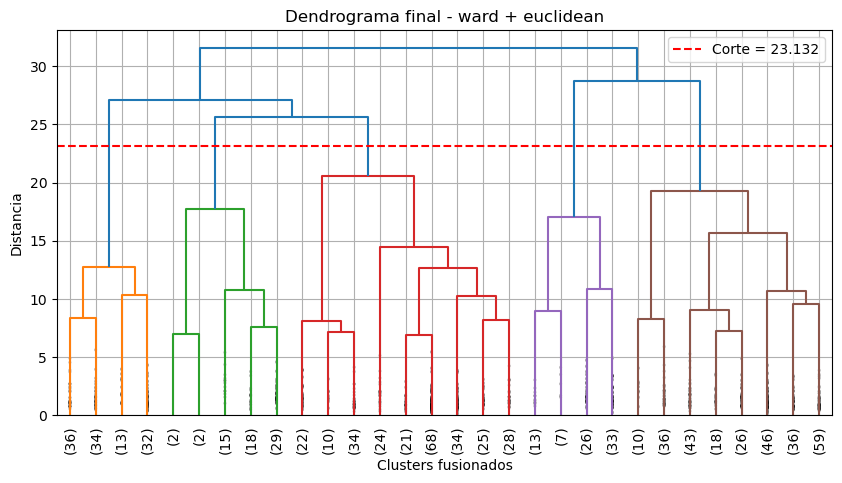

In [23]:
linkage_final = "ward"
metric_final = "euclidean"
k_final = 5

Z_final = construir_Z(X_dendro, linkage_final, metric_final)

lower = Z_final[-k_final, 2]

upper = Z_final[-(k_final - 1), 2]

cutoff_fixed = (lower + upper) / 2

labels_check = fcluster(Z_final, t=cutoff_fixed, criterion="distance")
n_clusters_check = len(np.unique(labels_check))

print("Lower:", round(lower, 4))
print("Upper:", round(upper, 4))
print("Corte determinista:", round(cutoff_fixed, 4))
print("Clusters obtenidos con ese corte:", n_clusters_check)

plt.figure(figsize=(10, 5))
dendrogram(
    Z_final,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)

plt.axhline(
    y=cutoff_fixed,
    c="r",
    linestyle="--",
    label=f"Corte = {cutoff_fixed:.3f}"
)

plt.title("Dendrograma final - ward + euclidean")
plt.xlabel("Clusters fusionados")
plt.ylabel("Distancia")
plt.grid(True)
plt.legend()
plt.show()

El dendrograma se cortó en una altura intermedia entre la última fusión que todavía mantiene 5 clusters y la siguiente fusión en la que los grupos ya pasan a ser 4. Para fijar ese punto, se tomó el promedio entre los niveles de distancia (lower y upper), lo que nos proporciona un corte estable que conserva exactamente 5 clusters. 

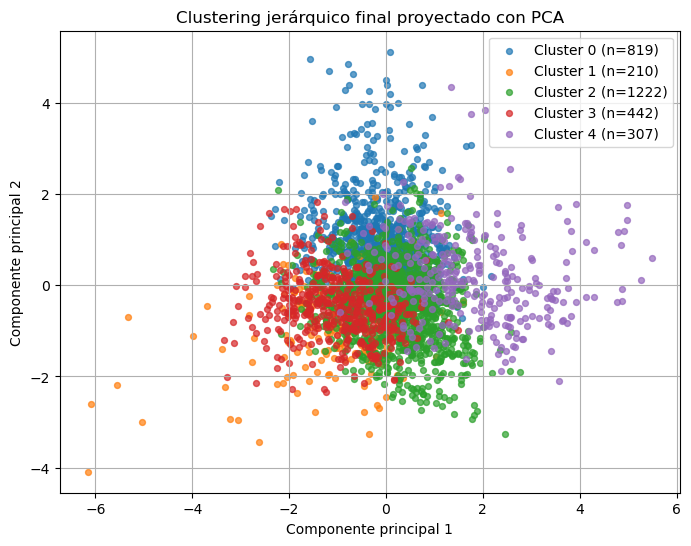

,cluster_hier,cantidad_personas
0,0,819
1,1,210
2,2,1222
3,3,442
4,4,307


In [24]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

k_final = 5

if "df_hier_final" not in globals():
    df_hier_final = X_hier.copy()

    model_hier_final = AgglomerativeClustering(
        n_clusters=k_final,
        linkage="ward"
    )
    df_hier_final["cluster_hier"] = model_hier_final.fit_predict(X_hier)

X_hier_vis = df_hier_final.drop(columns=["cluster_hier"]).copy()
y_hier_vis = df_hier_final["cluster_hier"].values

conteo_clusters = pd.Series(y_hier_vis).value_counts().sort_index()

pca_hier = PCA(n_components=2, random_state=314)
X_hier_pca = pca_hier.fit_transform(X_hier_vis)

plt.figure(figsize=(8, 6))
for c in np.unique(y_hier_vis):
    mask = y_hier_vis == c
    n_personas = conteo_clusters[c]
    plt.scatter(
        X_hier_pca[mask, 0],
        X_hier_pca[mask, 1],
        label=f"Cluster {c} (n={n_personas})",
        alpha=0.70,
        s=18
    )

plt.title("Clustering jerárquico final proyectado con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.grid(True)
plt.show()

resumen_clusters = conteo_clusters.reset_index()
resumen_clusters.columns = ["cluster_hier", "cantidad_personas"]
display(resumen_clusters)

### --> 2.3 DBSCAN

In [25]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

n_dbscan = min(10000, len(X_cluster)) #10000 por temas de capacidad de la máquina.
X_dbscan = X_cluster.sample(n=n_dbscan, random_state=314).copy()
print("Dimensión de la muestra para DBSCAN:", X_dbscan.shape)

min_samples = 5
print("min_samples elegido:", min_samples)


Dimensión de la muestra para DBSCAN: (10000, 13)
min_samples elegido: 5


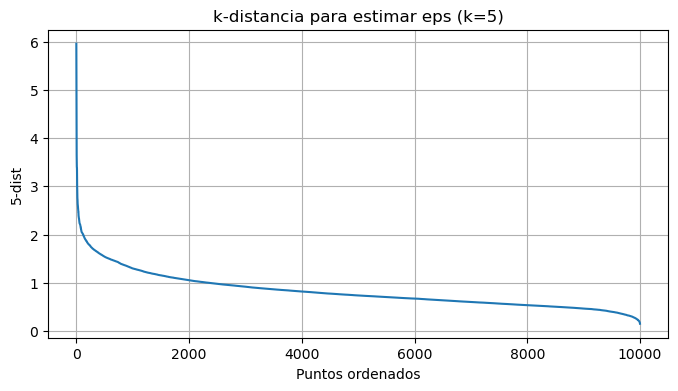

Percentiles de apoyo para elegir eps:
P90: 1.2990
P95: 1.5448
P97: 1.7013
P98: 1.8240
P99: 2.0425


In [26]:
# GRÁFICO DE K-DISTANCIA PARA ESTIMAR eps
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_dbscan)
dists, _ = nbrs.kneighbors(X_dbscan)

k_dists = np.sort(dists[:, -1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(k_dists)
plt.title(f"k-distancia para estimar eps (k={min_samples})")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"{min_samples}-dist")
plt.grid(True)
plt.show()

print("Percentiles de apoyo para elegir eps:")
for q in [90, 95, 97, 98, 99]:
    print(f"P{q}: {np.percentile(k_dists, q):.4f}")

In [27]:
# Prueba de Epsilon cercanos al codo
eps_candidates = [1.2990, 1.5448, 1.7013, 1.8240, 2.0425]

resultados_dbscan = []

for eps in eps_candidates:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_dbscan)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    prop_noise = n_noise / len(labels)

    resultados_dbscan.append({
        "eps": eps,
        "n_clusters": n_clusters,
        "n_noise": int(n_noise),
        "prop_noise": prop_noise
    })

df_resultados_dbscan = pd.DataFrame(resultados_dbscan)
display(df_resultados_dbscan)

,eps,n_clusters,n_noise,prop_noise
0,1.2990,4,599,0.0599
1,1.5448,2,267,0.0267
2,1.7013,1,145,0.0145
3,1.8240,1,92,0.0092
4,2.0425,2,41,0.0041


eps final: 1.299
min_samples: 5
Número de clusters encontrados: 4
Cantidad de puntos ruido: 599
Proporción de ruido: 0.0599

Frecuencia por etiqueta (-1 = ruido):


-1     599
 0    9381
 1      11
 2       4
 3       5
Name: count, dtype: int64

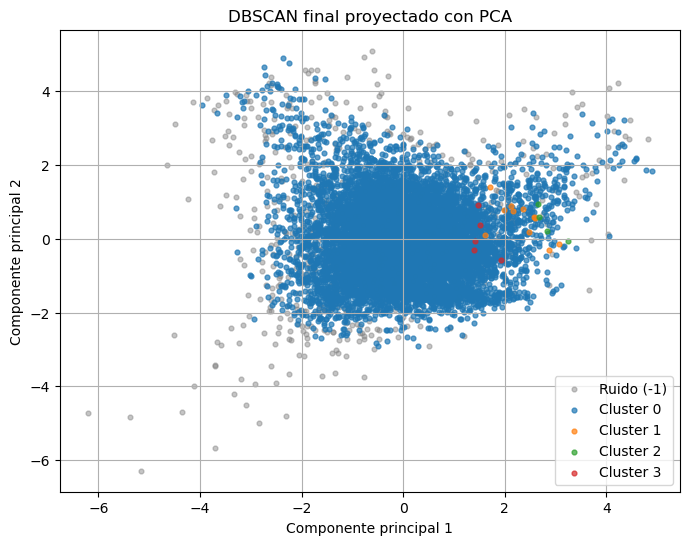

In [28]:
# MODELO FINAL DBSCAN
eps_final = 1.2990 # Mejor celda pasada
dbscan_final = DBSCAN(eps=eps_final, min_samples=min_samples)

labels_dbscan = dbscan_final.fit_predict(X_dbscan)

n_clusters_final = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_final = np.sum(labels_dbscan == -1)
prop_noise_final = n_noise_final / len(labels_dbscan)

print("eps final:", eps_final)
print("min_samples:", min_samples)
print("Número de clusters encontrados:", n_clusters_final)
print("Cantidad de puntos ruido:", n_noise_final)
print("Proporción de ruido:", round(prop_noise_final, 4))

print("\nFrecuencia por etiqueta (-1 = ruido):")
display(pd.Series(labels_dbscan).value_counts().sort_index())

from sklearn.decomposition import PCA

df_dbscan_final = X_dbscan.copy()
df_dbscan_final["cluster_dbscan"] = labels_dbscan

X_db_vis = df_dbscan_final.drop(columns=["cluster_dbscan"]).copy()
y_db_vis = df_dbscan_final["cluster_dbscan"].values

pca_db = PCA(n_components=2, random_state=314)
X_db_pca = pca_db.fit_transform(X_db_vis)

plt.figure(figsize=(8, 6))

for c in np.unique(y_db_vis):
    mask = y_db_vis == c
    if c == -1:
        plt.scatter(
            X_db_pca[mask, 0],
            X_db_pca[mask, 1],
            color="gray",
            label="Ruido (-1)",
            alpha=0.45,
            s=12
        )
    else:
        plt.scatter(
            X_db_pca[mask, 0],
            X_db_pca[mask, 1],
            label=f"Cluster {c}",
            alpha=0.70,
            s=12
        )

plt.title("DBSCAN final proyectado con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.grid(True)
plt.show()

Al probar distintos valores de EPSILON, DBSCAN no logró una segmentación equilibrada ni interpretable. La solución quedó dominada por un único cluster muy grande (9.381 observaciones), acompañado de pequeños grupos marginales y 599 puntos clasificados como ruido, lo que equivale a un 5,99% de la muestra. Además, como se puede observar en los datos y en el gráfico el modelo absorbió casi todos los datos en un solo grupo y dejó el resto como excepciones. Esto sugiere que la base no presenta una estructura de densidad bien definida para este método, por lo que K-means y el clustering jerárquico resultan más adecuados en este caso.

### --> 2.3 HDBSCAN

In [29]:
import hdbscan
X_hdb = X_dbscan.copy()

print("Dimensión muestra HDBSCAN:", X_hdb.shape)

Dimensión muestra HDBSCAN: (10000, 13)


In [30]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

param_grid = {
    "min_cluster_size": [25, 35, 50, 100],
    "min_samples": [5, 10, 15, 20]
}

resultados_hdbscan = []

for mcs in param_grid["min_cluster_size"]:
    for ms in param_grid["min_samples"]:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=mcs,
            min_samples=ms
        )
        
        labels = clusterer.fit_predict(X_hdb)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        prop_noise = n_noise / len(labels)
        
        labels_validos = labels[labels != -1]
        if len(labels_validos) > 0:
            sizes = pd.Series(labels_validos).value_counts()
            min_cluster_found = sizes.min()
            max_cluster_found = sizes.max()
        else:
            min_cluster_found = np.nan
            max_cluster_found = np.nan
        
        mask = labels != -1
        if n_clusters >= 2 and mask.sum() > n_clusters:
            sil = silhouette_score(X_hdb[mask], labels[mask])
            dbi = davies_bouldin_score(X_hdb[mask], labels[mask])
            chi = calinski_harabasz_score(X_hdb[mask], labels[mask])
        else:
            sil = np.nan
            dbi = np.nan
            chi = np.nan
        
        resultados_hdbscan.append({
            "min_cluster_size": mcs,
            "min_samples": ms,
            "n_clusters": n_clusters,
            "n_noise": int(n_noise),
            "prop_noise": prop_noise,
            "min_cluster_found": min_cluster_found,
            "max_cluster_found": max_cluster_found,
            "silhouette_sin_ruido": sil,
            "davies_bouldin_sin_ruido": dbi,
            "calinski_harabasz_sin_ruido": chi
        })

df_hdbscan = pd.DataFrame(resultados_hdbscan).sort_values(
    by=["n_clusters", "prop_noise"],
    ascending=[False, True]
)

display(df_hdbscan)

,min_cluster_size,min_samples,n_clusters,n_noise,prop_noise,min_cluster_found,max_cluster_found,silhouette_sin_ruido,davies_bouldin_sin_ruido,calinski_harabasz_sin_ruido
0,25,5,12,2945,0.2945,26,2098,0.059689,2.618239,262.860693
4,35,5,10,2860,0.2860,85,2098,0.058161,2.897393,305.151859
8,50,5,10,2860,0.2860,85,2098,0.058161,2.897393,305.151859
1,25,10,10,4149,0.4149,52,1879,0.059933,2.556760,280.783970
5,35,10,10,4149,0.4149,52,1879,0.059933,2.556760,280.783970
12,100,5,9,2802,0.2802,108,2241,0.057438,2.898138,309.935880
9,50,10,9,4102,0.4102,76,1879,0.081689,2.590105,316.901189
2,25,15,9,4985,0.4985,69,1709,0.096256,2.373324,298.938182
6,35,15,9,4985,0.4985,69,1709,0.096256,2.373324,298.938182
10,50,15,9,4985,0.4985,69,1709,0.096256,2.373324,298.938182


min_cluster_size final: 25
min_samples final: 5
Número de clusters encontrados: 12
Cantidad de puntos ruido: 2945
Proporción de ruido: 0.2945

Frecuencia por etiqueta (-1 = ruido):


-1     2945
 0      476
 1       26
 2      475
 3      169
 4      132
 5      772
 6       33
 7      757
 8       85
 9     2098
 10     108
 11    1924
Name: count, dtype: int64

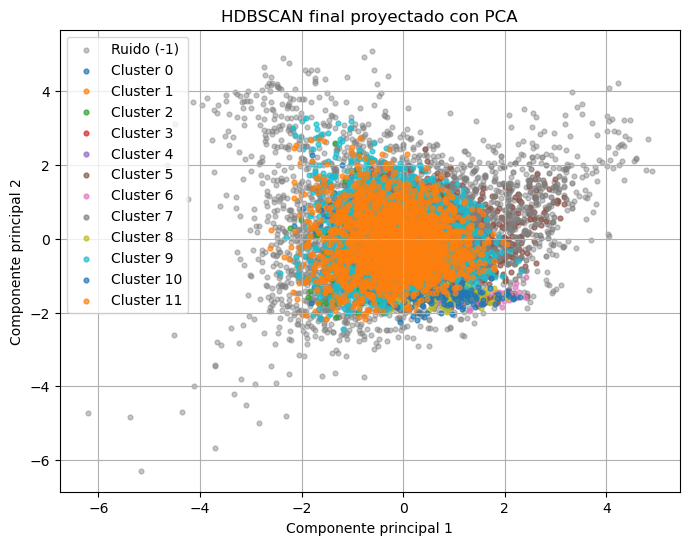

In [31]:
# Modelo final HDBSCAN
mcs_final = 25
ms_final = 5

hdb_final = hdbscan.HDBSCAN(
    min_cluster_size=mcs_final,
    min_samples=ms_final
)

labels_hdb = hdb_final.fit_predict(X_hdb)

n_clusters_final = len(set(labels_hdb)) - (1 if -1 in labels_hdb else 0)
n_noise_final = np.sum(labels_hdb == -1)
prop_noise_final = n_noise_final / len(labels_hdb)

print("min_cluster_size final:", mcs_final)
print("min_samples final:", ms_final)
print("Número de clusters encontrados:", n_clusters_final)
print("Cantidad de puntos ruido:", n_noise_final)
print("Proporción de ruido:", round(prop_noise_final, 4))

print("\nFrecuencia por etiqueta (-1 = ruido):")
display(pd.Series(labels_hdb).value_counts().sort_index())

df_hdb_final = X_hdb.copy()
df_hdb_final["cluster_hdbscan"] = labels_hdb

X_hdb_vis = df_hdb_final.drop(columns=["cluster_hdbscan"]).copy()
y_hdb_vis = df_hdb_final["cluster_hdbscan"].values

pca_hdb = PCA(n_components=2, random_state=314)
X_hdb_pca = pca_hdb.fit_transform(X_hdb_vis)

plt.figure(figsize=(8, 6))

for c in np.unique(y_hdb_vis):
    mask = y_hdb_vis == c
    if c == -1:
        plt.scatter(
            X_hdb_pca[mask, 0],
            X_hdb_pca[mask, 1],
            color="gray",
            label="Ruido (-1)",
            alpha=0.45,
            s=12
        )
    else:
        plt.scatter(
            X_hdb_pca[mask, 0],
            X_hdb_pca[mask, 1],
            label=f"Cluster {c}",
            alpha=0.70,
            s=12
        )

plt.title("HDBSCAN final proyectado con PCA")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.legend()
plt.grid(True)
plt.show()

Como se puede observar HDBSCAN, en teoría, permite detectar mejor estructuras con densidades distintas que DBSCAN, ya que no depende de un único valor de ε y se adapta a variaciones locales. De igual manera, en el presente caso no se observa una mejora significativa en la segmentación, ya que los clusters siguen siendo poco balanceados y con bastante presencia de ruido. Esto sugiere que la base no presenta una estructura de densidad lo suficientemente clara para este tipo de métodos. En consecuencia, aunque HDBSCAN es más flexible, no logra una solución superior en términos prácticos frente a K-means o el clustering jerárquico. Además se seleccionó el resultado con menos ruido el cual tiene una cantidad de 12 clusters, para así evitar aquellos puntos que no alcanzan la densidad mínima. 

## Parte 4: Interpretación sustantiva de los clústeres

### 1) K-means

In [32]:
from IPython.display import display, Markdown

def pick_col(df, candidates, required=True):
    """Devuelve la primera columna disponible dentro de una lista de candidatos."""
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"No se encontró ninguna de estas columnas: {candidates}")
    return None

def pct_text(p):
    if p >= 40:
        return "muy grande"
    elif p >= 20:
        return "grande"
    elif p >= 10:
        return "intermedio"
    else:
        return "pequeño"

def intensidad_z(z):
    az = abs(z)
    if az >= 1.5:
        return "muy marcado"
    elif az >= 1.0:
        return "marcado"
    elif az >= 0.5:
        return "moderado"
    else:
        return "leve"

def formatea_valor(x, dec=2):
    if pd.isna(x):
        return "NA"
    return f"{x:.{dec}f}"

def describe_cambio(z, var_meta):
    """
    Traduce el signo del z-score a una frase natural.
    Para variables donde 'menor' es mejor (ej. PREFERENCIA o LUGAR),
    se usan frases específicas.
    """
    nombre = var_meta["nombre"]
    
    if var_meta.get("tipo") == "invertida":
        
        if z <= -0.5:
            return f"{var_meta['bajo']}"
        elif z >= 0.5:
            return f"{var_meta['alto']}"
        else:
            return None
    else:
        if z >= 0.5:
            return f"{var_meta['alto']}"
        elif z <= -0.5:
            return f"{var_meta['bajo']}"
        else:
            return None

def nombre_perfil(row_z, pct, cols):
    """
    Asigna una etiqueta simple al cluster según los patrones más visibles.
    No es perfecta, pero ayuda mucho a comunicar.
    """
    score = row_z.get(cols["score"], 0)
    age   = row_z.get(cols["age"], 0)
    coh   = row_z.get(cols["coh"], 0)
    pref  = row_z.get(cols["pref"], 0)
    lugar = row_z.get(cols["lugar"], 0)
    apps  = row_z.get(cols["apps"], 0)

    if pct >= 40 and max(abs(score), abs(age), abs(coh), abs(pref), abs(lugar), abs(apps)) < 0.8:
        return "Perfil mayoritario o más representativo"
    if age >= 1.0:
        return "Estudiantes de mayor edad"
    if score >= 0.8:
        return "Perfil de mayor desempeño académico"
    if coh >= 0.8 and score < 0:
        return "Postulación coherente, pero con puntajes más bajos"
    if apps >= 0.8:
        return "Alta intensidad de postulación"
    if score <= -0.8 and coh <= -0.5:
        return "Perfil con resultados de ingreso más débiles"
    return "Perfil diferenciado respecto del promedio"


df_interpret = cluster_base.copy()
df_interpret["cluster_kmeans"] = labels_final

cluster_col = "cluster_kmeans"

score_col = pick_col(df_interpret, ["PUNTAJE_PONDERADO", "PUNTAJE"])
age_col   = pick_col(df_interpret, ["age", "Age"])
coh_col   = pick_col(df_interpret, ["coherence_5_0.05_", "coherence_5_0.05_imp"])
pref_col  = pick_col(df_interpret, ["PREFERENCIA"])
lugar_col = pick_col(df_interpret, ["LUGAR"])
apps_col  = pick_col(df_interpret, ["n_postulaciones", "CantPos"])

sexo_col    = pick_col(df_interpret, ["COD_SEXO"], required=False)
dep_col     = pick_col(df_interpret, ["DEPENDENCIA", "GRUPO_DEPENDENCIA"], required=False)
periodo_col = pick_col(df_interpret, ["CAT_PERIODO_1"], required=False)

cols = {
    "score": score_col,
    "age": age_col,
    "coh": coh_col,
    "pref": pref_col,
    "lugar": lugar_col,
    "apps": apps_col
}


meta = {
    score_col: {
        "nombre": "puntaje ponderado",
        "alto": "obtienen puntajes de ingreso más altos que el promedio",
        "bajo": "obtienen puntajes de ingreso más bajos que el promedio",
        "tipo": "normal"
    },
    age_col: {
        "nombre": "edad",
        "alto": "son estudiantes de mayor edad que el promedio",
        "bajo": "son estudiantes más jóvenes que el promedio",
        "tipo": "normal"
    },
    coh_col: {
        "nombre": "coherencia",
        "alto": "muestran un proceso de postulación más coherente o alineado",
        "bajo": "muestran un proceso de postulación menos coherente o más disperso",
        "tipo": "normal"
    },
    pref_col: {
        "nombre": "preferencia",
        "alto": "tienden a ubicar esta carrera en preferencias más bajas dentro de su lista",
        "bajo": "tienden a ubicar esta carrera en preferencias más altas dentro de su lista",
        "tipo": "invertida"
    },
    lugar_col: {
        "nombre": "lugar",
        "alto": "quedan en posiciones más rezagadas dentro del proceso",
        "bajo": "quedan en posiciones relativamente más favorables dentro del proceso",
        "tipo": "invertida"
    },
    apps_col: {
        "nombre": "número de postulaciones",
        "alto": "realizan más postulaciones que el promedio",
        "bajo": "realizan menos postulaciones que el promedio",
        "tipo": "normal"
    }
}

num_vars = [score_col, age_col, coh_col, pref_col, lugar_col, apps_col]

# Tamaño de clusters
cluster_sizes = (
    df_interpret[cluster_col]
    .value_counts()
    .sort_index()
    .to_frame("n")
)

cluster_sizes["pct"] = cluster_sizes["n"] / len(df_interpret) * 100

summary_num = (
    df_interpret
    .groupby(cluster_col)[num_vars]
    .agg(["mean", "median", "std"])
)

overall_mean = df_interpret[num_vars].mean()
overall_std = df_interpret[num_vars].std(ddof=0)

relative_profile = (
    df_interpret.groupby(cluster_col)[num_vars].mean()
    .subtract(overall_mean, axis=1)
    .divide(overall_std.replace(0, np.nan), axis=1)
)

display(Markdown("""
## Interpretación sustantiva de los clústeres según K-Means

A continuación se resume qué representa cada grupo de estudiantes de forma simple.  
La idea no es solo mostrar números, sino traducirlos a perfiles comprensibles.

**Qué significa cada variable principal:**
- **Puntaje ponderado:** resume el desempeño de ingreso del estudiante.
- **Edad:** permite distinguir perfiles más tradicionales o menos tradicionales.
- **Coherencia:** indica qué tan alineado o consistente parece su patrón de postulación.
- **Preferencia:** muestra en qué lugar de prioridad quedó la carrera dentro de la lista del estudiante.
- **Lugar:** refleja la posición obtenida en el proceso.
- **Número de postulaciones:** indica cuántas carreras o alternativas postuló el estudiante.

> **Importante:** en variables como **Preferencia** y **Lugar**, un número menor suele interpretarse como una mejor posición relativa.  
> Si en tu base eso funciona distinto, cambia esa interpretación.
"""))

display(Markdown("### Tamaño de los clústeres"))
display(cluster_sizes)

display(Markdown("### Resumen numérico por clúster (escala original)"))
display(summary_num)

display(Markdown("### Perfil relativo respecto del promedio general"))
display(relative_profile.round(3))

if sexo_col is not None:
    display(Markdown("### Distribución de sexo por clúster (%)"))
    sexo_dist = pd.crosstab(
        df_interpret[cluster_col],
        df_interpret[sexo_col],
        normalize="index"
    ) * 100
    display(sexo_dist.round(2))
else:
    sexo_dist = None

if dep_col is not None:
    display(Markdown("### Distribución del tipo de dependencia por clúster (%)"))
    dep_dist = pd.crosstab(
        df_interpret[cluster_col],
        df_interpret[dep_col],
        normalize="index"
    ) * 100
    display(dep_dist.round(2))
else:
    dep_dist = None

if periodo_col is not None:
    display(Markdown("### Distribución de CAT_PERIODO_1 por clúster (%)"))
    cat_periodo_dist = pd.crosstab(
        df_interpret[cluster_col],
        df_interpret[periodo_col],
        normalize="index"
    ) * 100
    display(cat_periodo_dist.round(2))

    if df_interpret[periodo_col].dropna().nunique() == 2:
        display(Markdown("### Promedio de CAT_PERIODO_1 por clúster"))
        periodo_mean = (
            df_interpret.groupby(cluster_col)[periodo_col]
            .mean()
            .to_frame("promedio_CAT_PERIODO_1")
        )
        display(periodo_mean.round(3))
    else:
        periodo_mean = None
else:
    cat_periodo_dist = None
    periodo_mean = None


display(Markdown("## Lectura sustantiva de cada clúster"))

global_period_mean = None
if periodo_col is not None and df_interpret[periodo_col].dropna().nunique() == 2:
    global_period_mean = df_interpret[periodo_col].mean()

resumen_final = []

for cl in sorted(df_interpret[cluster_col].unique()):
    n = int(cluster_sizes.loc[cl, "n"])
    pct = cluster_sizes.loc[cl, "pct"]

    row_means = df_interpret.groupby(cluster_col)[num_vars].mean().loc[cl]
    row_z = relative_profile.loc[cl]

    top_vars = row_z.abs().sort_values(ascending=False).index.tolist()
    frases = []

    for v in top_vars:
        frase = describe_cambio(row_z[v], meta[v])
        if frase is not None:
            frases.append((v, frase, intensidad_z(row_z[v]), row_z[v]))

    frases = frases[:3]

    perfil = nombre_perfil(row_z, pct, cols)

    texto = []
    texto.append(f"### Clúster {cl}: {perfil}")
    texto.append(
        f"Este grupo reúne **{n} estudiantes** ({pct:.1f}% de la muestra), por lo que corresponde a un clúster **{pct_text(pct)}**."
    )

    if len(frases) > 0:
        texto.append("En términos prácticos, este grupo se caracteriza porque:")
        for v, frase, inten, zval in frases:
            media_cluster = row_means[v]
            media_global = overall_mean[v]
            texto.append(
                f"- {frase.capitalize()} "
                f"(media del clúster = **{formatea_valor(media_cluster)}**, "
                f"promedio general = **{formatea_valor(media_global)}**; diferencia {inten})."
            )
    else:
        texto.append(
            "No presenta diferencias muy fuertes respecto del promedio general, por lo que puede leerse como un perfil bastante cercano al estudiante promedio."
        )

    score_z = row_z[score_col]
    age_z   = row_z[age_col]
    coh_z   = row_z[coh_col]
    pref_z  = row_z[pref_col]
    lug_z   = row_z[lugar_col]
    apps_z  = row_z[apps_col]

    interpretacion_humana = None

    if pct >= 40 and max(abs(score_z), abs(age_z), abs(coh_z), abs(pref_z), abs(lug_z), abs(apps_z)) < 0.8:
        interpretacion_humana = (
            "Mirado en conjunto, este parece ser el **perfil más representativo o más común** dentro de la base. "
            "No destaca por extremos muy marcados, por lo que puede entenderse como el grupo que más se aproxima al comportamiento general de la cohorte."
        )
    elif age_z >= 1.0:
        interpretacion_humana = (
            "Más allá de los números, este grupo parece recoger a estudiantes **menos tradicionales en edad**, "
            "es decir, personas que se alejan del perfil típico de ingreso inmediato después de egresar. "
            "Eso puede estar asociado a trayectorias educativas más discontinuas o a ingresos más tardíos al sistema."
        )
    elif score_z >= 0.8:
        interpretacion_humana = (
            "En términos simples, este clúster concentra a quienes muestran un **mejor desempeño de ingreso**. "
            "No significa necesariamente que sean 'mejores estudiantes' en todo sentido, pero sí que llegan con una ventaja clara en los indicadores académicos considerados."
        )
    elif coh_z >= 0.8 and score_z < 0:
        interpretacion_humana = (
            "Este grupo es interesante porque combina **mayor coherencia al postular** con **puntajes más bajos que el promedio**. "
            "Eso sugiere estudiantes que parecen tener una búsqueda más ordenada o enfocada, aunque sin destacar en resultados de ingreso."
        )
    elif apps_z >= 0.8:
        interpretacion_humana = (
            "Este perfil parece reflejar una **postulación más intensa o más activa**, ya que sus integrantes postulan a más alternativas. "
            "Dicho de forma simple, son estudiantes que exploran más opciones o enfrentan el proceso de forma más abierta."
        )
    elif score_z <= -0.8 and coh_z <= -0.5:
        interpretacion_humana = (
            "Este clúster parece agrupar estudiantes con una entrada **más débil o menos ventajosa** al sistema, "
            "tanto por resultados como por la forma en que se ordena su postulación. "
            "No debe leerse como una etiqueta definitiva, pero sí como una señal de mayor fragilidad relativa."
        )
    else:
        interpretacion_humana = (
            "En conjunto, este grupo no se explica por una sola variable, sino por una combinación de diferencias moderadas. "
            "Eso sugiere un perfil particular, aunque menos extremo que otros clústeres."
        )

    texto.append("")
    texto.append(interpretacion_humana)

    if sexo_dist is not None:
        fila_sexo = sexo_dist.loc[cl]
        sexo_dom = fila_sexo.idxmax()
        sexo_dom_pct = fila_sexo.max()
        if sexo_dom_pct >= 60:
            texto.append(
                f"Además, en composición por sexo predomina la categoría **{sexo_dom}** con **{sexo_dom_pct:.1f}%** del grupo, "
                "lo que indica una composición relativamente concentrada en esa categoría."
            )
        else:
            texto.append(
                "En cuanto al sexo, el grupo no muestra una concentración demasiado marcada en una sola categoría, "
                "por lo que esa variable no parece ser el rasgo principal que lo distingue."
            )

    if dep_dist is not None:
        fila_dep = dep_dist.loc[cl]
        dep_dom = fila_dep.idxmax()
        dep_dom_pct = fila_dep.max()
        if dep_dom_pct >= 50:
            texto.append(
                f"Respecto del tipo de dependencia escolar, predomina la categoría **{dep_dom}** con **{dep_dom_pct:.1f}%**, "
                "lo que sugiere que el origen escolar sí aporta a perfilar este grupo."
            )
        else:
            texto.append(
                "En el tipo de dependencia escolar no se observa una dominancia muy fuerte, "
                "así que este clúster parece explicarse más por desempeño, edad o patrón de postulación que por origen escolar."
            )

    if periodo_mean is not None and global_period_mean is not None:
        val = periodo_mean.loc[cl, "promedio_CAT_PERIODO_1"]
        if val > global_period_mean + 0.03:
            texto.append(
                f"Si se interpreta **CAT_PERIODO_1** como un indicador de continuidad o retención, este grupo muestra un valor **superior al promedio general** "
                f"({val:.3f} vs {global_period_mean:.3f}), por lo que podría tratarse de un perfil con mejor permanencia relativa."
            )
        elif val < global_period_mean - 0.03:
            texto.append(
                f"Si se interpreta **CAT_PERIODO_1** como un indicador de continuidad o retención, este grupo muestra un valor **inferior al promedio general** "
                f"({val:.3f} vs {global_period_mean:.3f}), lo que sugiere una trayectoria más frágil o menos estable en el corto plazo."
            )
        else:
            texto.append(
                f"En **CAT_PERIODO_1** este grupo no se aleja demasiado del promedio general "
                f"({val:.3f} vs {global_period_mean:.3f}), por lo que no parece diferenciarse fuertemente en esa dimensión."
            )

    display(Markdown("\n".join(texto)))

    resumen_final.append({
        "cluster": cl,
        "perfil_asignado": perfil,
        "n": n,
        "pct": round(pct, 2),
        "puntaje_promedio": row_means[score_col],
        "edad_promedio": row_means[age_col],
        "coherencia_promedio": row_means[coh_col],
        "preferencia_promedio": row_means[pref_col],
        "lugar_promedio": row_means[lugar_col],
        "postulaciones_promedio": row_means[apps_col]
    })


resumen_final = pd.DataFrame(resumen_final).sort_values("cluster")
display(Markdown("## Resumen ejecutivo de los perfiles"))
display(resumen_final)

display(Markdown("""
## Conclusión

En conjunto, los clústeres no parecen ser solo divisiones matemáticas arbitrarias.  
La segmentación logra separar grupos con diferencias visibles en **desempeño de ingreso, edad, coherencia del proceso de postulación, prioridad dada a la carrera y cantidad de postulaciones**.  

Dicho en simple, el modelo permite distinguir **tipos de estudiantes** y no solo “grupos numéricos”.  
Eso hace que la segmentación tenga valor práctico, porque ayuda a describir perfiles distintos dentro de la cohorte y abre la puerta a comparar su continuidad, permanencia o comportamiento posterior en el sistema.
"""))


## Interpretación sustantiva de los clústeres según K-Means

A continuación se resume qué representa cada grupo de estudiantes de forma simple.  
La idea no es solo mostrar números, sino traducirlos a perfiles comprensibles.

**Qué significa cada variable principal:**
- **Puntaje ponderado:** resume el desempeño de ingreso del estudiante.
- **Edad:** permite distinguir perfiles más tradicionales o menos tradicionales.
- **Coherencia:** indica qué tan alineado o consistente parece su patrón de postulación.
- **Preferencia:** muestra en qué lugar de prioridad quedó la carrera dentro de la lista del estudiante.
- **Lugar:** refleja la posición obtenida en el proceso.
- **Número de postulaciones:** indica cuántas carreras o alternativas postuló el estudiante.

> **Importante:** en variables como **Preferencia** y **Lugar**, un número menor suele interpretarse como una mejor posición relativa.  
> Si en tu base eso funciona distinto, cambia esa interpretación.


### Tamaño de los clústeres

,n,pct
cluster_kmeans,,
0,37453,5.718015
1,159655,24.374809
2,60816,9.284885
3,38443,5.869160
4,358633,54.753130


### Resumen numérico por clúster (escala original)

PUNTAJE_PONDERADO                           age         \
                            mean  median        std       mean median   
cluster_kmeans                                                          
0                     596.877229  594.90  63.704738  27.077377   26.0   
1                     582.256976  577.00  61.919493  20.315355   20.0   
2                     586.929301  583.00  62.999451  20.368768   20.0   
3                     649.025045  661.80  84.821306  20.187524   20.0   
4                     626.130633  622.75  71.668618  20.147703   20.0   

                         coherence_5_0.05_                     PREFERENCIA  \
                     std              mean    median       std        mean   
cluster_kmeans                                                               
0               4.201292          0.602973  0.333333  0.637759    1.440312   
1               1.214395          1.499896  1.333333  0.569409    1.393824   
2               1.337158          0.420042  0.266667  0.456745    5.412178   
3               1.119948          0.344616  0.166667  0.429854    1.518690   
4               1.008102          0.260292  0.166667  0.293778    1.445277   

                                      LUGAR                     \
               median       std        mean median         std   
cluster_kmeans                                                   
0                 1.0  0.888500   43.238459   31.0   43.717130   
1                 1.0  0.680589   44.934715   36.0   38.449531   
2                 5.0  2.476325   59.808274   46.0   51.797466   
3                 1.0  0.844858  317.208204  282.0  120.303670   
4                 1.0  0.679895   49.683738   39.0   41.573567   

               n_postulaciones                   
                          mean median       std  
cluster_kmeans                                   
0                     4.339145    4.0  2.416192  
1                     4.663593    4.0  2.253128  
2                     7.518022    8.0  2.200440  
3                     4.758682    4.0  2.171982  
4                     4.614494    4.0  2.310563

...

### Clúster 3: Perfil diferenciado respecto del promedio
Este grupo reúne **38443 estudiantes** (5.9% de la muestra), por lo que corresponde a un clúster **pequeño**.
En términos prácticos, este grupo se caracteriza porque:
- Quedan en posiciones más rezagadas dentro del proceso (media del clúster = **317.21**, promedio general = **64.80**; diferencia muy marcado).
- Obtienen puntajes de ingreso más altos que el promedio (media del clúster = **649.03**, promedio general = **611.47**; diferencia moderado).

En conjunto, este grupo no se explica por una sola variable, sino por una combinación de diferencias moderadas. Eso sugiere un perfil particular, aunque menos extremo que otros clústeres.
En cuanto al sexo, el grupo no muestra una concentración demasiado marcada en una sola categoría, por lo que esa variable no parece ser el rasgo principal que lo distingue.
Respecto del tipo de dependencia escolar, predomina la categoría **4.0** con **54.2%**, lo que sugiere que el origen escolar sí aporta a perfilar este grupo.
En **CAT_PERIODO_1** este grupo no se aleja demasiado del promedio general (0.800 vs 0.794), por lo que no parece diferenciarse fuertemente en esa dimensión.

### Clúster 4: Perfil mayoritario o más representativo
Este grupo reúne **358633 estudiantes** (54.8% de la muestra), por lo que corresponde a un clúster **muy grande**.
En términos prácticos, este grupo se caracteriza porque:
- Muestran un proceso de postulación menos coherente o más disperso (media del clúster = **0.26**, promedio general = **0.60**; diferencia moderado).

Mirado en conjunto, este parece ser el **perfil más representativo o más común** dentro de la base. No destaca por extremos muy marcados, por lo que puede entenderse como el grupo que más se aproxima al comportamiento general de la cohorte.
En cuanto al sexo, el grupo no muestra una concentración demasiado marcada en una sola categoría, por lo que esa variable no parece ser el rasgo principal que lo distingue.
Respecto del tipo de dependencia escolar, predomina la categoría **3.0** con **52.5%**, lo que sugiere que el origen escolar sí aporta a perfilar este grupo.
En **CAT_PERIODO_1** este grupo no se aleja demasiado del promedio general (0.822 vs 0.794), por lo que no parece diferenciarse fuertemente en esa dimensión.

## Resumen ejecutivo de los perfiles

,cluster,perfil_asignado,n,pct,puntaje_promedio,edad_promedio,coherencia_promedio,preferencia_promedio,lugar_promedio,postulaciones_promedio
0,0,Estudiantes de mayor edad,37453,5.72,596.877229,27.077377,0.602973,1.440312,43.238459,4.339145
1,1,"Postulación coherente, pero con puntajes más bajos",159655,24.37,582.256976,20.315355,1.499896,1.393824,44.934715,4.663593
2,2,Alta intensidad de postulación,60816,9.28,586.929301,20.368768,0.420042,5.412178,59.808274,7.518022
3,3,Perfil diferenciado respecto del promedio,38443,5.87,649.025045,20.187524,0.344616,1.518690,317.208204,4.758682
4,4,Perfil mayoritario o más representativo,358633,54.75,626.130633,20.147703,0.260292,1.445277,49.683738,4.614494



## Conclusión

En conjunto, los clústeres no parecen ser solo divisiones matemáticas arbitrarias.  
La segmentación logra separar grupos con diferencias visibles en **desempeño de ingreso, edad, coherencia del proceso de postulación, prioridad dada a la carrera y cantidad de postulaciones**.  

Dicho en simple, el modelo permite distinguir **tipos de estudiantes** y no solo “grupos numéricos”.  
Eso hace que la segmentación tenga valor práctico, porque ayuda a describir perfiles distintos dentro de la cohorte y abre la puerta a comparar su continuidad, permanencia o comportamiento posterior en el sistema.


### 2) Clustering Jerárquico

In [33]:
k_final = 5

if "df_hier_final" not in globals():
    from sklearn.cluster import AgglomerativeClustering

    df_hier_final = X_hier.copy()
    model_hier_final = AgglomerativeClustering(
        n_clusters=k_final,
        linkage="ward"
    )
    df_hier_final["cluster_hier"] = model_hier_final.fit_predict(X_hier)

if "cluster_base" in globals():
    base_interpretable = cluster_base.copy()
elif "base_final" in globals():
    base_interpretable = base_final.copy()
else:
    raise ValueError("No encontré una base interpretable. Necesitas tener 'cluster_base' o 'base_final'.")

base_hier_interpretable = base_interpretable.loc[X_hier.index].copy()

base_hier_interpretable["cluster_hier"] = df_hier_final["cluster_hier"].values

variables_preferidas = [
    "PUNTAJE_PONDERADO",
    "age",
    "coherence_5_0.05_",
    "n_postulaciones",
    "PREFERENCIA",
    "LUGAR",
    "COD_SEXO",
    "DEPENDENCIA",
    "CAT_PERIODO_1"
]

variables_uso = [c for c in variables_preferidas if c in base_hier_interpretable.columns]

num_cols = [
    c for c in variables_uso
    if pd.api.types.is_numeric_dtype(base_hier_interpretable[c]) and c != "cluster_hier"
]

cat_cols = [
    c for c in variables_uso
    if c not in num_cols and c != "cluster_hier"
]

print("Variables numéricas usadas:", num_cols)
print("Variables categóricas usadas:", cat_cols)

tam_clusters = (
    base_hier_interpretable["cluster_hier"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster_hier")
    .reset_index(name="n_personas")
)

tam_clusters["porcentaje"] = (
    100 * tam_clusters["n_personas"] / tam_clusters["n_personas"].sum()
).round(2)

print("\nTamaño de cada cluster:")
display(tam_clusters)

if len(num_cols) > 0:
    resumen_numerico = (
        base_hier_interpretable
        .groupby("cluster_hier")[num_cols]
        .agg(["mean", "median", "std"])
        .round(2)
    )

    print("\nResumen numérico por cluster:")
    display(resumen_numerico)

if len(num_cols) > 0:
    promedio_global = base_hier_interpretable[num_cols].mean()
    promedio_cluster = base_hier_interpretable.groupby("cluster_hier")[num_cols].mean()

    comparacion_global = (promedio_cluster - promedio_global).round(2)

    print("\nDiferencia del promedio del cluster respecto del promedio global:")
    display(comparacion_global)

def categoria_dominante(serie):
    s = serie.dropna()
    if len(s) == 0:
        return pd.Series({"categoria_dominante": np.nan, "pct_dominante": np.nan})
    moda = s.mode().iloc[0]
    pct = (s == moda).mean() * 100
    return pd.Series({
        "categoria_dominante": moda,
        "pct_dominante": round(pct, 2)
    })

resumen_categorico = None

if len(cat_cols) > 0:
    bloques_cat = []

    for col in cat_cols:
        tmp = (
            base_hier_interpretable
            .groupby("cluster_hier")[col]
            .apply(categoria_dominante)
            .unstack()
        )
        tmp.columns = [f"{col}_{c}" for c in tmp.columns]
        bloques_cat.append(tmp)

    resumen_categorico = pd.concat(bloques_cat, axis=1).reset_index()

    print("\nCategoría dominante por cluster:")
    display(resumen_categorico)

perfil_clusters = tam_clusters.copy()

if len(num_cols) > 0:
    medias_cluster = (
        base_hier_interpretable
        .groupby("cluster_hier")[num_cols]
        .mean()
        .round(2)
        .reset_index()
    )
    perfil_clusters = perfil_clusters.merge(medias_cluster, on="cluster_hier", how="left")

if resumen_categorico is not None:
    perfil_clusters = perfil_clusters.merge(resumen_categorico, on="cluster_hier", how="left")

print("\nPerfil consolidado de clusters:")
display(perfil_clusters)

for col in cat_cols:
    print(f"\nDistribución de {col} por cluster:")
    tabla_dist = pd.crosstab(
        base_hier_interpretable["cluster_hier"],
        base_hier_interpretable[col],
        normalize="index"
    ).round(3) * 100
    display(tabla_dist)

def interpretar_nivel(valor_cluster, valor_global, tolerancia_rel=0.05):
    if pd.isna(valor_cluster) or pd.isna(valor_global):
        return "sin información suficiente"

    if valor_global == 0:
        if valor_cluster > 0:
            return "por sobre el promedio general"
        elif valor_cluster < 0:
            return "por debajo del promedio general"
        else:
            return "alineado con el promedio general"

    dif_rel = (valor_cluster - valor_global) / abs(valor_global)

    if dif_rel > tolerancia_rel:
        return "por sobre el promedio general"
    elif dif_rel < -tolerancia_rel:
        return "por debajo del promedio general"
    else:
        return "cercano al promedio general"

def tamanio_relativo(n_cluster, total):
    prop = n_cluster / total
    if prop >= 0.30:
        return "uno de los grupos más grandes"
    elif prop <= 0.10:
        return "uno de los grupos más pequeños"
    else:
        return "un grupo de tamaño intermedio"

total_obs = len(base_hier_interpretable)

global_means = {}
for col in num_cols:
    global_means[col] = base_hier_interpretable[col].mean()

print("\n" + "="*70)
print("INTERPRETACIÓN AUTOMÁTICA DE LOS CLUSTERS JERÁRQUICOS")
print("="*70)

for _, row in perfil_clusters.sort_values("cluster_hier").iterrows():
    c = int(row["cluster_hier"])
    n = int(row["n_personas"])
    pct = row["porcentaje"]

    frases = []
    frases.append(
        f"Cluster {c}: agrupa a {n} personas ({pct:.1f}% de la muestra), por lo que corresponde a {tamanio_relativo(n, total_obs)}."
    )

    for col in num_cols:
        nivel = interpretar_nivel(row[col], global_means[col])
        frases.append(
            f"En {col}, este grupo se ubica {nivel}, con un promedio de {row[col]:.2f}."
        )

    for col in cat_cols:
        col_cat = f"{col}_categoria_dominante"
        col_pct = f"{col}_pct_dominante"

        if col_cat in perfil_clusters.columns and col_pct in perfil_clusters.columns:
            frases.append(
                f"En {col}, predomina la categoría {row[col_cat]} con una participación de {row[col_pct]:.1f}% dentro del cluster."
            )

    print("\n" + " ".join(frases))

print("\n" + "="*70)
print("ETIQUETAS INTERPRETATIVAS SUGERIDAS")
print("="*70)

for _, row in perfil_clusters.sort_values("cluster_hier").iterrows():
    c = int(row["cluster_hier"])

    etiquetas = []

    if "PUNTAJE_PONDERADO" in num_cols:
        nivel_puntaje = interpretar_nivel(row["PUNTAJE_PONDERADO"], global_means["PUNTAJE_PONDERADO"])
        if "por sobre" in nivel_puntaje:
            etiquetas.append("mayor rendimiento académico")
        elif "por debajo" in nivel_puntaje:
            etiquetas.append("menor rendimiento académico")
        else:
            etiquetas.append("rendimiento académico intermedio")

    if "coherence_5_0.05_" in num_cols:
        nivel_coh = interpretar_nivel(row["coherence_5_0.05_"], global_means["coherence_5_0.05_"])
        if "por sobre" in nivel_coh:
            etiquetas.append("mayor consistencia/coherencia")
        elif "por debajo" in nivel_coh:
            etiquetas.append("menor consistencia/coherencia")

    if "n_postulaciones" in num_cols:
        nivel_post = interpretar_nivel(row["n_postulaciones"], global_means["n_postulaciones"])
        if "por sobre" in nivel_post:
            etiquetas.append("más activo en postulaciones")
        elif "por debajo" in nivel_post:
            etiquetas.append("menos activo en postulaciones")

    if len(etiquetas) == 0:
        etiquetas.append("perfil general/intermedio")

    print(f"Cluster {c}: " + " | ".join(etiquetas))

Variables numéricas usadas: ['PUNTAJE_PONDERADO', 'age', 'coherence_5_0.05_', 'n_postulaciones', 'PREFERENCIA', 'LUGAR', 'COD_SEXO', 'DEPENDENCIA', 'CAT_PERIODO_1']
Variables categóricas usadas: []

Tamaño de cada cluster:


,cluster_hier,n_personas,porcentaje
0,0,819,27.30
1,1,210,7.00
2,2,1222,40.73
3,3,442,14.73
4,4,307,10.23



Resumen numérico por cluster:


PUNTAJE_PONDERADO                   age               \
                          mean  median    std   mean median   std   
cluster_hier                                                        
0                       590.98  587.00  61.65  20.29   20.0  1.32   
1                       608.80  613.00  63.22  25.79   24.0  4.65   
2                       622.33  616.58  76.24  20.06   20.0  0.91   
3                       612.67  610.42  73.36  20.33   20.0  1.57   
4                       645.65  655.00  81.76  20.07   20.0  0.92   

             coherence_5_0.05_              n_postulaciones               \
                          mean median   std            mean median   std   
cluster_hier                                                               
0                         0.49   0.33  0.47            7.30    7.0  1.98   
1                         0.48   0.33  0.55            3.83    3.0  1.96   
2                         0.35   0.17  0.42            3.74    4.0  1.75   
3                         1.70   1.67  0.61            4.00    4.0  1.72   
4                         0.35   0.17  0.46            4.94    5.0  2.21   

             PREFERENCIA                LUGAR                COD_SEXO         \
                    mean median   std    mean median     std     mean median   
cluster_hier                                                                   
0                   2.53    2.0  2.25   49.54   41.0   38.82     1.50    1.0   
1                   1.38    1.0  0.74   41.16   27.0   40.79     1.40    1.0   
2                   1.55    1.0  0.81   42.85   36.0   33.58     1.53    2.0   
3                   1.36    1.0  0.65   35.28   25.0   35.17     1.50    2.0   
4                   1.62    1.0  0.99  253.49  207.0  129.64     1.42    1.0   

                   DEPENDENCIA              CAT_PERIODO_1               
               std        mean median   std          mean median   std  
cluster_hier                                                            
0             0.50        2.79    3.0  0.78          0.79    1.0  0.41  
1             0.49        2.88    3.0  0.99          0.82    1.0  0.39  
2             0.50        2.96    3.0  1.01          0.80    1.0  0.40  
3             0.50        2.98    3.0  0.77          0.76    1.0  0.42  
4             0.49        3.30    3.0  0.81          0.83    1.0  0.38


Diferencia del promedio del cluster respecto del promedio global:


,PUNTAJE_PONDERADO,age,coherence_5_0.05_,n_postulaciones,PREFERENCIA,LUGAR,COD_SEXO,DEPENDENCIA,CAT_PERIODO_1
cluster_hier,,,,,,,,,
0,-22.81,-0.27,-0.11,2.42,0.75,-15.46,0.00,-0.15,-0.01
1,-4.99,5.22,-0.12,-1.05,-0.41,-23.84,-0.10,-0.07,0.03
2,8.54,-0.51,-0.24,-1.14,-0.24,-22.14,0.03,0.01,0.00
3,-1.11,-0.24,1.10,-0.88,-0.43,-29.72,0.01,0.04,-0.03
4,31.86,-0.49,-0.25,0.06,-0.16,188.49,-0.08,0.35,0.03



Perfil consolidado de clusters:


,cluster_hier,n_personas,porcentaje,PUNTAJE_PONDERADO,age,coherence_5_0.05_,n_postulaciones,PREFERENCIA,LUGAR,COD_SEXO,DEPENDENCIA,CAT_PERIODO_1
0,0,819,27.30,590.98,20.29,0.49,7.30,2.53,49.54,1.50,2.79,0.79
1,1,210,7.00,608.80,25.79,0.48,3.83,1.38,41.16,1.40,2.88,0.82
2,2,1222,40.73,622.33,20.06,0.35,3.74,1.55,42.85,1.53,2.96,0.80
3,3,442,14.73,612.67,20.33,1.70,4.00,1.36,35.28,1.50,2.98,0.76
4,4,307,10.23,645.65,20.07,0.35,4.94,1.62,253.49,1.42,3.30,0.83



INTERPRETACIÓN AUTOMÁTICA DE LOS CLUSTERS JERÁRQUICOS

Cluster 0: agrupa a 819 personas (27.3% de la muestra), por lo que corresponde a un grupo de tamaño intermedio. En PUNTAJE_PONDERADO, este grupo se ubica cercano al promedio general, con un promedio de 590.98. En age, este grupo se ubica cercano al promedio general, con un promedio de 20.29. En coherence_5_0.05_, este grupo se ubica por debajo del promedio general, con un promedio de 0.49. En n_postulaciones, este grupo se ubica por sobre el promedio general, con un promedio de 7.30. En PREFERENCIA, este grupo se ubica por sobre el promedio general, con un promedio de 2.53. En LUGAR, este grupo se ubica por debajo del promedio general, con un promedio de 49.54. En COD_SEXO, este grupo se ubica cercano al promedio general, con un promedio de 1.50. En DEPENDENCIA, este grupo se ubica por debajo del promedio general, con un promedio de 2.79. En CAT_PERIODO_1, este grupo se ubica cercano al promedio general, con un promedio de 0.79.



### 3) DBSCAN: no fue analizado

### 4) HDBSCAN

In [34]:
model_hdbscan_final = None
X_hdb_model = None
labels_hdb = None
probabilities_hdb = None
outlier_scores_hdb = None
cluster_persistence = None

backend_name = None

if "hdb_final" in globals() and hasattr(hdb_final, "labels_"):
    model_hdbscan_final = hdb_final
    backend_name = type(hdb_final).__module__

    if "X_hdb" in globals():
        X_hdb_model = X_hdb.copy()
    elif "df_hdb_final" in globals():
        X_hdb_model = df_hdb_final.drop(
            columns=[c for c in ["cluster_hdbscan", "probability_hdbscan", "outlier_score_hdbscan"] if c in df_hdb_final.columns],
            errors="ignore"
        ).copy()
    else:
        raise ValueError("Existe hdb_final, pero no encontré X_hdb ni df_hdb_final para recuperar la base modelada.")

    labels_hdb = np.asarray(getattr(model_hdbscan_final, "labels_"))
    probabilities_hdb = getattr(model_hdbscan_final, "probabilities_", None)
    outlier_scores_hdb = getattr(model_hdbscan_final, "outlier_scores_", None)
    cluster_persistence = getattr(model_hdbscan_final, "cluster_persistence_", None)

elif "df_hdb_final" in globals() and "cluster_hdbscan" in df_hdb_final.columns:
    X_hdb_model = df_hdb_final.drop(
        columns=[c for c in ["cluster_hdbscan", "probability_hdbscan", "outlier_score_hdbscan"] if c in df_hdb_final.columns],
        errors="ignore"
    ).copy()

    labels_hdb = df_hdb_final["cluster_hdbscan"].to_numpy()
    probabilities_hdb = df_hdb_final["probability_hdbscan"].to_numpy() if "probability_hdbscan" in df_hdb_final.columns else None
    outlier_scores_hdb = df_hdb_final["outlier_score_hdbscan"].to_numpy() if "outlier_score_hdbscan" in df_hdb_final.columns else None

    if "hdb_final" in globals() and hasattr(hdb_final, "labels_") and len(hdb_final.labels_) == len(labels_hdb):
        model_hdbscan_final = hdb_final
        backend_name = type(hdb_final).__module__
        cluster_persistence = getattr(hdb_final, "cluster_persistence_", None)
    else:
        backend_name = "desconocido (solo labels guardadas)"

else:
    try:
        import hdbscan
        HDBSCAN_Model = hdbscan.HDBSCAN
        backend_name = "hdbscan"
    except Exception:
        from sklearn.cluster import HDBSCAN as HDBSCAN_Model
        backend_name = "sklearn.cluster.HDBSCAN"

    if "X_hdb" in globals():
        X_hdb_model = X_hdb.copy()
    elif "X_hdbscan" in globals():
        X_hdb_model = X_hdbscan.copy()
    elif "X_cluster" in globals():
        X_hdb_model = X_cluster.copy()
    else:
        raise ValueError("No encontré una base para HDBSCAN. Necesitas X_hdb, X_hdbscan o X_cluster.")

    mcs_used = globals().get("mcs_final", globals().get("min_cluster_size_final", 25))
    ms_used = globals().get("ms_final", globals().get("min_samples_final", 5))
    metric_used = globals().get("metric_hdb_final", "euclidean")
    cluster_selection_method_used = globals().get("cluster_selection_method_final", "eom")
    cluster_selection_epsilon_used = globals().get("cluster_selection_epsilon_final", 0.0)

    if "hdbscan" in backend_name:
        model_hdbscan_final = HDBSCAN_Model(
            min_cluster_size=mcs_used,
            min_samples=ms_used,
            metric=metric_used,
            cluster_selection_method=cluster_selection_method_used,
            cluster_selection_epsilon=cluster_selection_epsilon_used,
            prediction_data=True
        )
    else:
        model_hdbscan_final = HDBSCAN_Model(
            min_cluster_size=mcs_used,
            min_samples=ms_used,
            metric=metric_used,
            cluster_selection_method=cluster_selection_method_used,
            cluster_selection_epsilon=cluster_selection_epsilon_used,
            allow_single_cluster=False,
            n_jobs=-1
        )

    model_hdbscan_final.fit(X_hdb_model)

    labels_hdb = np.asarray(model_hdbscan_final.labels_)
    probabilities_hdb = getattr(model_hdbscan_final, "probabilities_", None)
    outlier_scores_hdb = getattr(model_hdbscan_final, "outlier_scores_", None)
    cluster_persistence = getattr(model_hdbscan_final, "cluster_persistence_", None)

if X_hdb_model is None or labels_hdb is None:
    raise ValueError("No se pudo recuperar correctamente la solución final de HDBSCAN.")

if len(X_hdb_model) != len(labels_hdb):
    raise ValueError(
        f"Inconsistencia detectada: X_hdb_model tiene {len(X_hdb_model)} filas y labels_hdb tiene {len(labels_hdb)} etiquetas."
    )

df_hdb_final = X_hdb_model.copy()
df_hdb_final["cluster_hdbscan"] = labels_hdb

if probabilities_hdb is not None and len(probabilities_hdb) == len(df_hdb_final):
    df_hdb_final["probability_hdbscan"] = probabilities_hdb

if outlier_scores_hdb is not None and len(outlier_scores_hdb) == len(df_hdb_final):
    df_hdb_final["outlier_score_hdbscan"] = outlier_scores_hdb

mcs_used = globals().get("mcs_final", getattr(model_hdbscan_final, "min_cluster_size", np.nan))
ms_used = globals().get("ms_final", getattr(model_hdbscan_final, "min_samples", np.nan))
metric_used = getattr(model_hdbscan_final, "metric", globals().get("metric_hdb_final", "euclidean"))
cluster_selection_method_used = getattr(
    model_hdbscan_final,
    "cluster_selection_method",
    globals().get("cluster_selection_method_final", "eom")
)

print("Backend HDBSCAN usado:", backend_name)
print("Shape base modelada:", X_hdb_model.shape)

labels_series = pd.Series(labels_hdb, name="cluster_hdbscan")
labels_validos = labels_series[labels_series != -1]

n_total = len(labels_series)
n_ruido = int((labels_series == -1).sum())
n_asignados = n_total - n_ruido
clusters_reales = sorted(labels_validos.unique())
n_clusters_reales = len(clusters_reales)
pct_ruido = 100 * n_ruido / n_total

resumen_general_hdb = pd.DataFrame({
    "n_total": [n_total],
    "n_clusters_reales": [n_clusters_reales],
    "n_asignados_cluster": [n_asignados],
    "n_ruido": [n_ruido],
    "pct_ruido": [round(pct_ruido, 2)],
    "min_cluster_size": [mcs_used],
    "min_samples": [ms_used],
    "metric": [metric_used],
    "cluster_selection_method": [cluster_selection_method_used]
})

print("\nResumen general de la solución HDBSCAN:")
display(resumen_general_hdb)

metricas_hdb = pd.DataFrame(columns=["Silhouette", "Davies_Bouldin", "Calinski_Harabasz"])

if n_clusters_reales >= 2 and n_asignados >= 2:
    mask_valid = labels_hdb != -1
    X_valid = X_hdb_model.loc[mask_valid] if isinstance(X_hdb_model, pd.DataFrame) else X_hdb_model[mask_valid]
    y_valid = labels_hdb[mask_valid]

    sil_sample_size = min(5000, len(X_valid))

    silhouette_hdb = silhouette_score(
        X_valid,
        y_valid,
        sample_size=sil_sample_size,
        random_state=314
    )
    dbi_hdb = davies_bouldin_score(X_valid, y_valid)
    ch_hdb = calinski_harabasz_score(X_valid, y_valid)

    metricas_hdb = pd.DataFrame({
        "Silhouette": [round(silhouette_hdb, 6)],
        "Davies_Bouldin": [round(dbi_hdb, 6)],
        "Calinski_Harabasz": [round(ch_hdb, 6)]
    })

print("\nMétricas internas sobre puntos asignados a clusters (sin ruido):")
display(metricas_hdb)

tam_hdb = (
    labels_series
    .value_counts()
    .sort_index()
    .rename_axis("cluster_hdbscan")
    .reset_index(name="n_personas")
)

tam_hdb["porcentaje"] = (100 * tam_hdb["n_personas"] / tam_hdb["n_personas"].sum()).round(2)
tam_hdb["tipo"] = np.where(tam_hdb["cluster_hdbscan"] == -1, "Ruido", "Cluster")

print("\nTamaño de clusters y ruido:")
display(tam_hdb)

if probabilities_hdb is not None:
    resumen_prob = (
        pd.DataFrame({
            "cluster_hdbscan": labels_hdb,
            "probability_hdbscan": probabilities_hdb
        })
        .groupby("cluster_hdbscan")["probability_hdbscan"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .round(4)
        .reset_index()
    )

    print("\nResumen de probabilidad/confianza por cluster:")
    display(resumen_prob)

if outlier_scores_hdb is not None:
    resumen_outlier = (
        pd.DataFrame({
            "cluster_hdbscan": labels_hdb,
            "outlier_score_hdbscan": outlier_scores_hdb
        })
        .groupby("cluster_hdbscan")["outlier_score_hdbscan"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .round(4)
        .reset_index()
    )

    print("\nResumen de outlier scores por cluster:")
    display(resumen_outlier)

if cluster_persistence is not None and len(cluster_persistence) == len(clusters_reales):
    persistencia_df = pd.DataFrame({
        "cluster_hdbscan": clusters_reales,
        "cluster_persistence": np.round(cluster_persistence, 4)
    }).sort_values("cluster_persistence", ascending=False).reset_index(drop=True)

    print("\nPersistencia de clusters:")
    display(persistencia_df)
else:
    persistencia_df = None

if "cluster_base" in globals():
    base_interpretable = cluster_base.copy()
elif "base_final" in globals():
    base_interpretable = base_final.copy()
else:
    raise ValueError("No encontré 'cluster_base' ni 'base_final' para interpretar HDBSCAN.")

base_hdb_interpretable = base_interpretable.loc[X_hdb_model.index].copy()
base_hdb_interpretable["cluster_hdbscan"] = labels_hdb

if probabilities_hdb is not None and len(probabilities_hdb) == len(base_hdb_interpretable):
    base_hdb_interpretable["probability_hdbscan"] = probabilities_hdb

if outlier_scores_hdb is not None and len(outlier_scores_hdb) == len(base_hdb_interpretable):
    base_hdb_interpretable["outlier_score_hdbscan"] = outlier_scores_hdb

num_cols_pref = [
    "PUNTAJE_PONDERADO",
    "age",
    "coherence_5_0.05_",
    "n_postulaciones"
]

cat_cols_pref = [
    "PREFERENCIA",
    "LUGAR",
    "COD_SEXO",
    "DEPENDENCIA",
    "CAT_PERIODO_1"
]

num_cols = [c for c in num_cols_pref if c in base_hdb_interpretable.columns]
cat_cols = [c for c in cat_cols_pref if c in base_hdb_interpretable.columns]

print("\nVariables numéricas usadas:", num_cols)
print("Variables categóricas usadas:", cat_cols)

base_hdb_clusters = base_hdb_interpretable[base_hdb_interpretable["cluster_hdbscan"] != -1].copy()

if len(base_hdb_clusters) == 0:
    print("\nHDBSCAN clasificó todo como ruido. No hay clusters reales que perfilar.")
else:
    tam_clusters_reales = (
        base_hdb_clusters["cluster_hdbscan"]
        .value_counts()
        .sort_index()
        .rename_axis("cluster_hdbscan")
        .reset_index(name="n_personas")
    )

    tam_clusters_reales["porcentaje_sobre_total"] = (
        100 * tam_clusters_reales["n_personas"] / len(base_hdb_interpretable)
    ).round(2)

    tam_clusters_reales["porcentaje_sobre_asignados"] = (
        100 * tam_clusters_reales["n_personas"] / len(base_hdb_clusters)
    ).round(2)

    print("\nTamaño de clusters reales:")
    display(tam_clusters_reales)

    if len(num_cols) > 0:
        resumen_num_hdb = (
            base_hdb_clusters
            .groupby("cluster_hdbscan")[num_cols]
            .agg(["mean", "median", "std"])
            .round(2)
        )

        print("\nResumen numérico por cluster real:")
        display(resumen_num_hdb)

        promedio_global_hdb = base_hdb_interpretable[num_cols].mean()
        promedio_cluster_hdb = base_hdb_clusters.groupby("cluster_hdbscan")[num_cols].mean()

        diff_global_hdb = (promedio_cluster_hdb - promedio_global_hdb).round(2)

        print("\nDiferencia del promedio del cluster respecto del promedio global:")
        display(diff_global_hdb)

    def categoria_dominante(serie):
        s = serie.dropna()
        if len(s) == 0:
            return pd.Series({"categoria_dominante": np.nan, "pct_dominante": np.nan})
        moda = s.mode().iloc[0]
        pct = (s == moda).mean() * 100
        return pd.Series({
            "categoria_dominante": moda,
            "pct_dominante": round(pct, 2)
        })

    resumen_categorico_hdb = None

    if len(cat_cols) > 0:
        bloques_cat_hdb = []

        for col in cat_cols:
            tmp = (
                base_hdb_clusters
                .groupby("cluster_hdbscan")[col]
                .apply(categoria_dominante)
                .unstack()
            )
            tmp.columns = [f"{col}_{c}" for c in tmp.columns]
            bloques_cat_hdb.append(tmp)

        resumen_categorico_hdb = pd.concat(bloques_cat_hdb, axis=1).reset_index()

        print("\nCategoría dominante por cluster real:")
        display(resumen_categorico_hdb)

    perfil_hdb = tam_clusters_reales.copy()

    if len(num_cols) > 0:
        medias_hdb = (
            base_hdb_clusters
            .groupby("cluster_hdbscan")[num_cols]
            .mean()
            .round(2)
            .reset_index()
        )
        perfil_hdb = perfil_hdb.merge(medias_hdb, on="cluster_hdbscan", how="left")

    if resumen_categorico_hdb is not None:
        perfil_hdb = perfil_hdb.merge(resumen_categorico_hdb, on="cluster_hdbscan", how="left")

    if probabilities_hdb is not None:
        prob_cluster_hdb = (
            base_hdb_clusters
            .groupby("cluster_hdbscan")["probability_hdbscan"]
            .mean()
            .round(4)
            .reset_index(name="probabilidad_media")
        )
        perfil_hdb = perfil_hdb.merge(prob_cluster_hdb, on="cluster_hdbscan", how="left")

    if outlier_scores_hdb is not None:
        out_cluster_hdb = (
            base_hdb_clusters
            .groupby("cluster_hdbscan")["outlier_score_hdbscan"]
            .mean()
            .round(4)
            .reset_index(name="outlier_score_medio")
        )
        perfil_hdb = perfil_hdb.merge(out_cluster_hdb, on="cluster_hdbscan", how="left")

    if persistencia_df is not None:
        perfil_hdb = perfil_hdb.merge(persistencia_df, on="cluster_hdbscan", how="left")

    print("\nPerfil consolidado de clusters HDBSCAN:")
    display(perfil_hdb)

    for col in cat_cols:
        print(f"\nDistribución de {col} por cluster real:")
        tabla_dist = pd.crosstab(
            base_hdb_clusters["cluster_hdbscan"],
            base_hdb_clusters[col],
            normalize="index"
        ).round(3) * 100
        display(tabla_dist)

    if n_ruido > 0:
        base_ruido_hdb = base_hdb_interpretable[base_hdb_interpretable["cluster_hdbscan"] == -1].copy()

        print("\nResumen del ruido (-1):")

        resumen_ruido = pd.DataFrame({
            "n_ruido": [len(base_ruido_hdb)],
            "pct_ruido": [round(100 * len(base_ruido_hdb) / len(base_hdb_interpretable), 2)]
        })

        if probabilities_hdb is not None:
            resumen_ruido["probabilidad_media"] = round(base_ruido_hdb["probability_hdbscan"].mean(), 4)

        if outlier_scores_hdb is not None:
            resumen_ruido["outlier_score_medio"] = round(base_ruido_hdb["outlier_score_hdbscan"].mean(), 4)

        display(resumen_ruido)

        if len(num_cols) > 0:
            print("\nPromedios del ruido en variables numéricas:")
            display(base_ruido_hdb[num_cols].mean().round(2).to_frame("media_ruido"))

    def interpretar_nivel(valor_cluster, valor_global, tolerancia_rel=0.05):
        if pd.isna(valor_cluster) or pd.isna(valor_global):
            return "sin información suficiente"

        if valor_global == 0:
            if valor_cluster > 0:
                return "por sobre el promedio general"
            elif valor_cluster < 0:
                return "por debajo del promedio general"
            else:
                return "alineado con el promedio general"

        dif_rel = (valor_cluster - valor_global) / abs(valor_global)

        if dif_rel > tolerancia_rel:
            return "por sobre el promedio general"
        elif dif_rel < -tolerancia_rel:
            return "por debajo del promedio general"
        else:
            return "cercano al promedio general"

    def tamanio_relativo(n_cluster, total_asignados):
        prop = n_cluster / total_asignados
        if prop >= 0.35:
            return "uno de los clusters dominantes"
        elif prop <= 0.12:
            return "uno de los clusters más pequeños"
        else:
            return "un cluster de tamaño intermedio"

    def diagnostico_ruido(pct):
        if pct < 10:
            return "bajo"
        elif pct < 25:
            return "moderado"
        elif pct < 40:
            return "alto"
        else:
            return "muy alto"

    print("\n" + "="*75)
    print("INTERPRETACIÓN AUTOMÁTICA DE LA SOLUCIÓN HDBSCAN")
    print("="*75)

    frases_globales = []
    frases_globales.append(
        f"La solución HDBSCAN identifica {n_clusters_reales} clusters reales y clasifica {n_ruido} observaciones como ruido, equivalente a un {pct_ruido:.1f}% del total."
    )
    frases_globales.append(
        f"El nivel de ruido observado puede considerarse {diagnostico_ruido(pct_ruido)} dentro de la muestra analizada."
    )

    if len(metricas_hdb) > 0:
        frases_globales.append(
            f"Sobre los puntos efectivamente asignados a clusters, la solución obtiene un Silhouette de {metricas_hdb.iloc[0]['Silhouette']:.4f}, un Davies-Bouldin de {metricas_hdb.iloc[0]['Davies_Bouldin']:.4f} y un Calinski-Harabasz de {metricas_hdb.iloc[0]['Calinski_Harabasz']:.4f}."
        )

    if probabilities_hdb is not None:
        frases_globales.append(
            f"La probabilidad media de pertenencia permite evaluar qué tan confiables son las asignaciones realizadas por el algoritmo."
        )

    if outlier_scores_hdb is not None:
        frases_globales.append(
            f"Los outlier scores complementan la lectura anterior, ya que valores más altos sugieren observaciones periféricas o menos representativas dentro de cada grupo."
        )

    if persistencia_df is not None:
        frases_globales.append(
            f"La persistencia de cluster permite evaluar la estabilidad relativa de cada grupo detectado por HDBSCAN."
        )

    print(" ".join(frases_globales))
    print()

    global_means_hdb = {}
    for col in num_cols:
        global_means_hdb[col] = base_hdb_interpretable[col].mean()

    for _, row in perfil_hdb.sort_values("cluster_hdbscan").iterrows():
        c = int(row["cluster_hdbscan"])
        n = int(row["n_personas"])
        pct_total = row["porcentaje_sobre_total"]
        pct_asig = row["porcentaje_sobre_asignados"]

        frases = []
        frases.append(
            f"Cluster {c}: reúne {n} observaciones, lo que representa el {pct_total:.1f}% del total y el {pct_asig:.1f}% de los casos asignados a clusters, por lo que corresponde a {tamanio_relativo(n, len(base_hdb_clusters))}."
        )

        for col in num_cols:
            nivel = interpretar_nivel(row[col], global_means_hdb[col])
            frases.append(
                f"En {col}, este grupo se ubica {nivel}, con un promedio de {row[col]:.2f}."
            )

        for col in cat_cols:
            col_cat = f"{col}_categoria_dominante"
            col_pct = f"{col}_pct_dominante"

            if col_cat in perfil_hdb.columns and col_pct in perfil_hdb.columns:
                frases.append(
                    f"En {col}, predomina la categoría {row[col_cat]} con una participación de {row[col_pct]:.1f}% dentro del cluster."
                )

        if "probabilidad_media" in perfil_hdb.columns:
            frases.append(
                f"La probabilidad media de asignación del cluster es {row['probabilidad_media']:.3f}, lo que entrega una idea de su estabilidad interna."
            )

        if "outlier_score_medio" in perfil_hdb.columns:
            frases.append(
                f"Su outlier score medio es {row['outlier_score_medio']:.3f}, indicador útil para detectar qué tan periférico es este grupo."
            )

        if "cluster_persistence" in perfil_hdb.columns:
            frases.append(
                f"La persistencia del cluster es {row['cluster_persistence']:.3f}, lo que ayuda a evaluar la robustez del grupo dentro de la jerarquía de densidades."
            )

        print(" ".join(frases))
        print()

    if n_ruido > 0:
        frases_ruido = []
        frases_ruido.append(
            f"El conjunto etiquetado como ruido concentra {n_ruido} observaciones ({pct_ruido:.1f}% del total), es decir, casos que HDBSCAN no asigna a ningún cluster estable."
        )

        if probabilities_hdb is not None:
            frases_ruido.append(
                f"Estos casos presentan una probabilidad media de pertenencia de {base_ruido_hdb['probability_hdbscan'].mean():.3f}, normalmente inferior a la de los clusters reales."
            )

        if outlier_scores_hdb is not None:
            frases_ruido.append(
                f"Además, su outlier score medio alcanza {base_ruido_hdb['outlier_score_hdbscan'].mean():.3f}, lo que refuerza la idea de que se trata de observaciones atípicas, fronterizas o difíciles de agrupar con confianza."
            )

        print(" ".join(frases_ruido))
        print()

    print("="*75)
    print("ETIQUETAS INTERPRETATIVAS SUGERIDAS PARA HDBSCAN")
    print("="*75)

    for _, row in perfil_hdb.sort_values("cluster_hdbscan").iterrows():
        c = int(row["cluster_hdbscan"])
        etiquetas = []

        if "PUNTAJE_PONDERADO" in num_cols:
            nivel_puntaje = interpretar_nivel(row["PUNTAJE_PONDERADO"], global_means_hdb["PUNTAJE_PONDERADO"])
            if "por sobre" in nivel_puntaje:
                etiquetas.append("mayor rendimiento académico")
            elif "por debajo" in nivel_puntaje:
                etiquetas.append("menor rendimiento académico")
            else:
                etiquetas.append("rendimiento académico intermedio")

        if "coherence_5_0.05_" in num_cols:
            nivel_coh = interpretar_nivel(row["coherence_5_0.05_"], global_means_hdb["coherence_5_0.05_"])
            if "por sobre" in nivel_coh:
                etiquetas.append("mayor consistencia/coherencia")
            elif "por debajo" in nivel_coh:
                etiquetas.append("menor consistencia/coherencia")

        if "n_postulaciones" in num_cols:
            nivel_post = interpretar_nivel(row["n_postulaciones"], global_means_hdb["n_postulaciones"])
            if "por sobre" in nivel_post:
                etiquetas.append("más activo en postulaciones")
            elif "por debajo" in nivel_post:
                etiquetas.append("menos activo en postulaciones")

        if "probabilidad_media" in perfil_hdb.columns:
            if row["probabilidad_media"] >= 0.80:
                etiquetas.append("asignación muy confiable")
            elif row["probabilidad_media"] >= 0.60:
                etiquetas.append("asignación moderadamente confiable")
            else:
                etiquetas.append("asignación menos estable")

        if "cluster_persistence" in perfil_hdb.columns:
            if row["cluster_persistence"] >= 0.70:
                etiquetas.append("cluster muy persistente")
            elif row["cluster_persistence"] >= 0.40:
                etiquetas.append("persistencia intermedia")
            else:
                etiquetas.append("cluster menos persistente")

        if len(etiquetas) == 0:
            etiquetas.append("perfil general/intermedio")

        print(f"Cluster {c}: " + " | ".join(etiquetas))

Backend HDBSCAN usado: hdbscan.hdbscan_
Shape base modelada: (10000, 13)

Resumen general de la solución HDBSCAN:


,n_total,n_clusters_reales,n_asignados_cluster,n_ruido,pct_ruido,min_cluster_size,min_samples,metric,cluster_selection_method
0,10000,12,7055,2945,29.45,25,5,euclidean,eom



Métricas internas sobre puntos asignados a clusters (sin ruido):


,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,0.060638,2.618239,262.860693



Tamaño de clusters y ruido:


...


Resumen del ruido (-1):


,n_ruido,pct_ruido,probabilidad_media,outlier_score_medio
0,2945,29.45,0.0,0.1941



Promedios del ruido en variables numéricas:


,media_ruido
PUNTAJE_PONDERADO,607.36
age,21.75
coherence_5_0.05_,0.81
n_postulaciones,5.26



INTERPRETACIÓN AUTOMÁTICA DE LA SOLUCIÓN HDBSCAN
La solución HDBSCAN identifica 12 clusters reales y clasifica 2945 observaciones como ruido, equivalente a un 29.4% del total. El nivel de ruido observado puede considerarse alto dentro de la muestra analizada. Sobre los puntos efectivamente asignados a clusters, la solución obtiene un Silhouette de 0.0606, un Davies-Bouldin de 2.6182 y un Calinski-Harabasz de 262.8607. La probabilidad media de pertenencia permite evaluar qué tan confiables son las asignaciones realizadas por el algoritmo. Los outlier scores complementan la lectura anterior, ya que valores más altos sugieren observaciones periféricas o menos representativas dentro de cada grupo. La persistencia de cluster permite evaluar la estabilidad relativa de cada grupo detectado por HDBSCAN.

Cluster 0: reúne 476 observaciones, lo que representa el 4.8% del total y el 6.8% de los casos asignados a clusters, por lo que corresponde a uno de los clusters más pequeños. En PUNTAJE_POND

## ---> Zona Comparativa 4 métodos

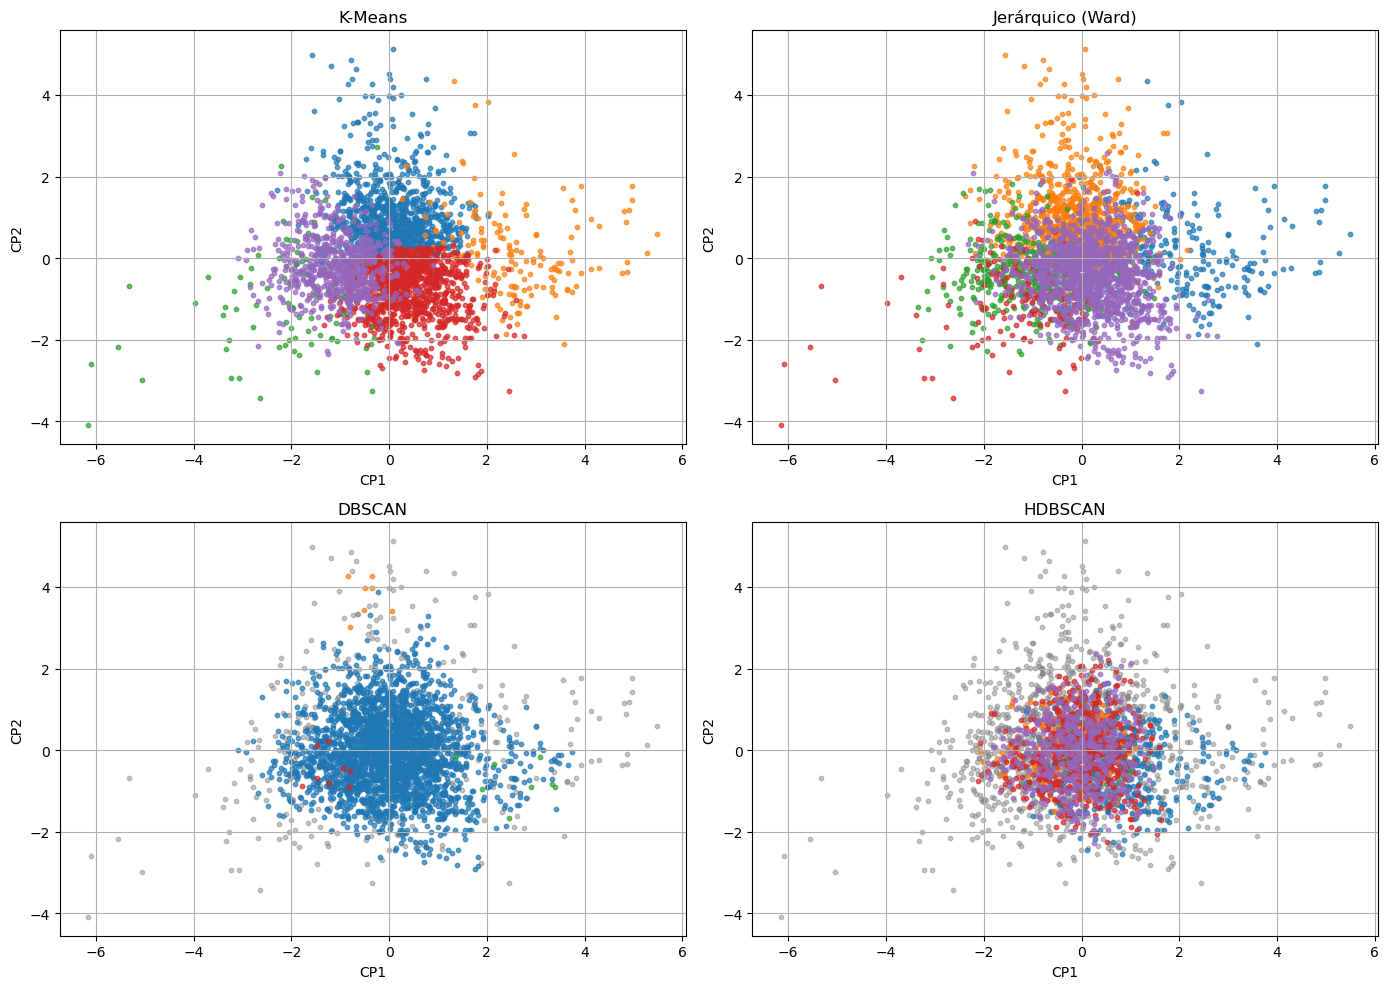

In [35]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import linkage, fcluster

n_vis_common = 3000
X_vis_common = X_cluster.sample(n=n_vis_common, random_state=314).copy()

pca_common = PCA(n_components=2, random_state=314)
X_vis_pca = pca_common.fit_transform(X_vis_common)

#K-MEANS
km_vis = KMeans(n_clusters=5, random_state=314, n_init=10)
labels_km_vis = km_vis.fit_predict(X_vis_common)

#Clustering Jerárquico
Z_vis = linkage(np.asarray(X_vis_common), method="ward")
lower_vis = Z_vis[-5, 2]
upper_vis = Z_vis[-4, 2]
cutoff_vis = (lower_vis + upper_vis) / 2
labels_hier_vis = fcluster(Z_vis, t=cutoff_vis, criterion="distance") - 1

#DBSCAN
dbscan_vis = DBSCAN(eps=eps_final, min_samples=min_samples)
labels_db_vis = dbscan_vis.fit_predict(X_vis_common)

#HDBSCAN
hdb_vis = hdbscan.HDBSCAN(
    min_cluster_size=mcs_final,
    min_samples=ms_final
)
labels_hdb_vis = hdb_vis.fit_predict(X_vis_common)

#Graf
def plot_clusters(ax, X_2d, labels, title):
    unique_labels = np.unique(labels)
    for c in unique_labels:
        mask = labels == c
        if c == -1:
            ax.scatter(
                X_2d[mask, 0],
                X_2d[mask, 1],
                color="gray",
                alpha=0.45,
                s=10,
                label="Ruido (-1)"
            )
        else:
            ax.scatter(
                X_2d[mask, 0],
                X_2d[mask, 1],
                alpha=0.70,
                s=10,
                label=f"C{c}"
            )
    ax.set_title(title)
    ax.set_xlabel("CP1")
    ax.set_ylabel("CP2")
    ax.grid(True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_clusters(axes[0, 0], X_vis_pca, labels_km_vis, "K-Means")
plot_clusters(axes[0, 1], X_vis_pca, labels_hier_vis, "Jerárquico (Ward)")
plot_clusters(axes[1, 0], X_vis_pca, labels_db_vis, "DBSCAN")
plot_clusters(axes[1, 1], X_vis_pca, labels_hdb_vis, "HDBSCAN")

plt.tight_layout()
plt.show()

Al analizar todos los métodos y los resultados, los grupos más interpretables los produce K-means, porque entrega 5 clusters relativamente claros, con tamaños bastante más útiles para perfilar y sin dejar puntos fuera. El más robusto también diría que es K-means, porque mantiene buen desempeño en varias métricas internas y no depende tanto de decisiones delicadas como el corte del dendrograma o los parámetros de densidad como es el HDBSCAN. En cuanto a separar mejor perfiles distintos, ahí K-means y el jerárquico compiten, pero en el presente trabajo se puede ver que domina levemente K-means, ya que el jerárquico también usa 5 grupos, pero sus métricas finales quedaron más débiles y la visualización no se ve mejor. Finalmente, el método que deja más observaciones como ruido es HDBSCAN, por lejos, ya que este clasifica 5.312 puntos como ruido (53,12%), mientras que DBSCAN deja 599 (5,99%); por eso, aunque ambos métodos de densidad fueron probados, en esta base no resultaron tan útiles como K-means o el clustering jerárquico.

## PARTE 5: Discución Final

1. ¿Qué método de clustering les pareció más adecuado para este problema y por qué?
2. ¿Los clústeres encontrados parecen tener sentido sustantivo o sólo matemático?
3. ¿Qué limitaciones tiene esta segmentación?
4. ¿Qué variables adicionales podrían mejorar el análisis?

1. El método más adecuado para resolver el problema fue K-means, ya que fue el que mejor se ajustó a los datos y el que mejor resultados proporcionó, encontrando 5 clusters.
2. Los clusteres encontrados, específicamente el de K-means, parecen tener sentido sustantivo y no solo matemático, ya que permiten distinguir perfiles estudiantiles con diferencias en variables como puntaje, edad, coherencia, número de postulaciones y preferencia. Es decir, no son grupos armados al azar, sino se ven patrones que podrían interpretarse en términos reales dentro del proceso de admisión. De todos modos, esa interpretación es más clara en K-means y en parte en el jerárquico, ya que que en DBSCAN y HDBSCAN los resultados fueron menos útiles, porque concentraron demasiados casos en un solo grupo o en ruido.
3. Una de las limitaciones que se observaron fue el mal ajuste que tuvo DBSCAN con los dataset y uno muy importantes que al realizar el Sioulette se tuvo que utilizar una muestra aleatoria de 10.000 en vez de los 655.000 datos, debido a que la mayoría de los computadores de hoy en día no tienen la capacidad para resolver eso. A su vez existe otra limitación con respecto a la variable n_postulaciones, la cual nos da a conocer la cantidad de veces que una persona postuló a diferentes carreras dentro del periodo. Esta variable fue construida contando el número de registros de postulaciones asociados a cada mrinanio.
4. Variables que tengan poca correlación entre ellas, como podría ser nivel socioeconómico, ubicación geográfica y rendimiento escolar previo (INGRESO_BRUTO_FAM, NOMBRE_COMUNA_EGRESO, NOMBRE_REGION_EGRESO, PROMEDIO_NOTAS, PTJE_NEM, PTJE_RANKING).